# Dissertation Suryer data Analysis
* RQ1 How does visualising the underlying values affect users’ perceptions of the chatbots?
* RQ2 How do different chatbot influence user percepetion of percived trust, autonomy, competence, and feeling informed?
* RQ3 How does co-design compare with standard charts?

 - Chatbot A = Non-visualisation
 - Chatbot B = Bar chart condition
  - Chatbot C = Radar Chart Condition
  - Chatbot D = Customer Chart Condition

### Step 1: Import Libraries

In [6]:
import pandas as pd
import numpy as np
import pingouin as pg
from scipy import stats
from scipy.stats import ttest_rel
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from itertools import combinations
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import friedmanchisquare
import warnings
warnings.filterwarnings('ignore')
print("All libraries loaded successfully!")

All libraries loaded successfully!


### Step 1.5: Define Helper Functions

Centralised helper functions used throughout the notebook for
consistent statistical reporting:

- format_p_value(): APA-style p-value formatting
- interpret_cohens_dz(): magnitude interpretation for paired effect sizes
- interpret_partial_eta_squared(): magnitude interpretation for ANOVA
  effect sizes
- cronbach_alpha(): internal consistency reliability coefficient

Defining these functions in one location ensures consistency across
all analyses and reduces code duplication. Each function references
the relevant methodological literature in its docstring.

In [ ]:
def format_p_value(p):
    """
    Format p-value for thesis-style reporting.

    Returns "p < .001" if p < 0.001, otherwise formats as "= 0.XXX".
    """
    if p < 0.001:
        return "p < .001"
    else:
        return f"{p:.3f}"


def interpret_cohens_dz(dz):
    """
    Interpret Cohen's dz magnitude using extended thresholds.

    Reference:
    Sawilowsky (2009) originally proposed the "very large" (1.2)
    and "very small" (0.01) thresholds in the context of Cohen's
    d for between-subjects designs. The same thresholds are
    applied here to Cohen's dz for paired-samples designs. 
    while acknowledging that dz values are typically larger than d for
    the same underlying effect because dz uses the standard
    deviation of difference scores (which removes between-subjects
    variability) rather than pooled SD (Lakens, 2013).
    
    Cohen, J. (1988). Statistical power analysis for the behavioral
    sciences (2nd ed.). Lawrence Erlbaum Associates.
    
    Lakens, D. (2013). Calculating and reporting effect sizes to
    facilitate cumulative science: A practical primer for t-tests
    and ANOVAs. Frontiers in Psychology, 4, 863.

    Sawilowsky, S. S. (2009). New effect size rules of thumb. Journal
    of Modern Applied Statistical Methods, 8(2), 597-599.

    Thresholds:
        |dz| >= 1.2  : Very large (Sawilowsky 2009 extension)
        |dz| >= 0.8  : Large       (Cohen 1988)
        |dz| >= 0.5  : Medium      (Cohen 1988)
        |dz| >= 0.2  : Small       (Cohen 1988)
        |dz| <  0.2  : Very small  (Sawilowsky 2009 extension)
    """
    abs_dz = abs(dz)
    if abs_dz >= 1.2:
        return "Very large"
    elif abs_dz >= 0.8:
        return "Large"
    elif abs_dz >= 0.5:
        return "Medium"
    elif abs_dz >= 0.2:
        return "Small"
    else:
        return "Very small"


def interpret_partial_eta_squared(eta_sq):
    """
    Interpret partial eta-squared magnitude per Cohen (1988).

    Reference:
    Cohen, J. (1988). Statistical power analysis for the behavioral
    sciences (2nd ed.). Lawrence Erlbaum Associates.

    Thresholds:
        eta square >= 0.14  : Large
        eta square >= 0.06  : Medium
        eta square >= 0.01  : Small
        eta square <  0.01  : Very small
    """
    if eta_sq >= 0.14:
        return "Large"
    elif eta_sq >= 0.06:
        return "Medium"
    elif eta_sq >= 0.01:
        return "Small"
    else:
        return "Very small"


def cronbach_alpha(items_df):
    """
    Compute Cronbach's alpha for a set of items.

    Reference:
    Tavakol, M., & Dennick, R. (2011). Making sense of Cronbach's alpha. International Journal of Medical Education, 2, 53-55.

    Formula:
        alpha = (k / (k-1)) * (1 - sum(item_variances) / total_variance)

    where k is the number of items.
    """
    items_df = items_df.dropna()
    item_variances = items_df.var(axis=0, ddof=1)
    total_scores = items_df.sum(axis=1)
    total_variance = total_scores.var(ddof=1)
    n_items = items_df.shape[1]
    return (n_items / (n_items - 1)) * (1 - item_variances.sum() / total_variance)
def interpret_cronbach_alpha(alpha):
    """
    Interpret Cronbach's alpha magnitude using standard thresholds.

    Thresholds:
        alpha >= 0.90  : Excellent
        alpha >= 0.80  : Good
        alpha >= 0.70  : Acceptable
        alpha >= 0.60  : Questionable
        alpha >= 0.50  : Poor
        alpha <  0.50  : Unacceptable
    """
    if alpha >= 0.90:
        return "Excellent"
    elif alpha >= 0.80:
        return "Good"
    elif alpha >= 0.70:
        return "Acceptable"
    elif alpha >= 0.60:
        return "Questionable"
    elif alpha >= 0.50:
        return "Poor"
    else:
        return "Unacceptable"
def interpret_significance(p, alpha=0.05):
    """
    Determine whether a p-value is statistically significant at a
    given alpha level.

    Parameters:
        p: p-value to evaluate
        alpha: significance threshold (default 0.05)

    Returns:
        "Yes" if p < alpha, "No" otherwise.
    """
    return "Yes" if p < alpha else "No"

### Step 2: Load Dataset and Inspect Structure

- This step loads the main questionnaire dataset and inspects its basic structure: number of rows, number of columns, number of participants, condition labels, and a preview of the first five rows.

- The dataset contains responses from 30 participants who each experienced four conditions (Chatbot A, B, C, D), giving 120 rows in total. Each row corresponds to one participant-condition combination and includes their item-level responses (Q1-Q22) and their condition assignment.

In [306]:
user_surveys_df = pd.read_excel('dissertation_collected_dataset.xlsx', sheet_name=0)

# Check basic info
print(f"Dataset shape: {user_surveys_df.shape[0]} rows x {user_surveys_df.shape[1]} columns")
print(f"Participants: {user_surveys_df['Participant_ID'].nunique()}")
print(f"Conditions: {user_surveys_df['Condition'].unique()}")
print(f"\nColumn names:\n{list(user_surveys_df.columns)}")
print(f"\nFirst 5 rows:")
user_surveys_df.head()

Dataset shape: 120 rows x 33 columns
Participants: 30
Conditions: <StringArray>
['Chatbot_A', 'Chatbot_B', 'Chatbot_C', 'Chatbot_D']
Length: 4, dtype: str

Column names:
['Participant_ID', 'Condition', 'Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10', 'Q11', 'Q7_r', 'Q8_r', 'Q9_r', 'Q10_r', 'Q11_r', 'Q12', 'Q13', 'Q14', 'Q15', 'Q16', 'Q17', 'Q18', 'Q19', 'Q20', 'Q21a', 'Q21b', 'Q21c', 'Q21d', 'Q21e', 'Q22']

First 5 rows:


,Participant_ID,Condition,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,...,Q17,Q18,Q19,Q20,Q21a,Q21b,Q21c,Q21d,Q21e,Q22
0,P01,Chatbot_A,4,5,4,5,5,4,4,4,...,4,5,3,3,4,5,3,3,4,5
1,P01,Chatbot_B,6,5,6,6,7,6,3,3,...,5,5,5,7,6,3,3,6,7,6
2,P01,Chatbot_C,5,5,5,5,5,6,4,3,...,5,3,5,5,6,3,3,6,7,5
3,P01,Chatbot_D,5,7,6,6,5,5,2,3,...,6,4,5,7,7,3,3,6,7,6
4,P02,Chatbot_A,4,5,4,4,5,4,4,4,...,4,4,3,3,4,3,3,4,4,3


### Step 3: Verify Data Structure and Check for Missing Values

In [307]:
academic_spark_chatbot_condition = {
    "Chatbot_A": "A", # non-visualisation
    "Chatbot_B": "B", # bar chart visualisation
    "Chatbot_C": "C", # radar chart visualisation
    "Chatbot_D": "D"  # Co-design(Polar bar chart) visualisation
}
# The Condition column is converted to a Categorical with explicit ordering (A < B < C < D) to ensure consistent display order 
# across all subsequent tables, plots, and analyses.
user_surveys_df["Condition"] = user_surveys_df["Condition"].map(academic_spark_chatbot_condition)
user_surveys_df["Condition"] = pd.Categorical(
    user_surveys_df["Condition"],
    categories=["A", "B", "C", "D"],
    ordered=True
)
# Verify cleaning
print(f"Conditions in dataset: {user_surveys_df['Condition'].unique()}")
print(f"\nRows per condition:")
print(user_surveys_df["Condition"].value_counts().sort_index())
print(f"\nAny missing values in user surveys dataset: {user_surveys_df.isnull().sum().sum()}")

Conditions in dataset: ['A', 'B', 'C', 'D']
Categories (4, str): ['A' < 'B' < 'C' < 'D']

Rows per condition:
Condition
A    30
B    30
C    30
D    30
Name: count, dtype: int64

Any missing values in user surveys dataset: 0


### Step 4: Verify Reverse Scoring of Trust Items
- The Trust scale includes 12 items: five reverse-worded items (Q7-Q11) and seven positive-worded items (Q12-Q18). The reverse-worded items have been pre-processed into separate columns (Q7_r through Q11_r) using the formula:

   **reversed_score = 8 - original_score**

- For each pair, the original and reversed scores should sum to 8 in every row. Any mismatches would indicate a data entry or transformation error that must be corrected before further analysis.

In [308]:
reverse_pairs_for_trust_scale = [
    ("Q7", "Q7_r"),
    ("Q8", "Q8_r"),
    ("Q9", "Q9_r"),
    ("Q10", "Q10_r"),
    ("Q11", "Q11_r")
]

for orig, rev in reverse_pairs_for_trust_scale:
    mismatches = user_surveys_df[user_surveys_df[orig] + user_surveys_df[rev] != 8][["Participant_ID", "Condition", orig, rev]]
    print(f"{orig} / {rev} -> mismatches: {len(mismatches)}")
    if len(mismatches) > 0:
        display(mismatches.head())

Q7 / Q7_r -> mismatches: 0
Q8 / Q8_r -> mismatches: 0
Q9 / Q9_r -> mismatches: 0
Q10 / Q10_r -> mismatches: 0
Q11 / Q11_r -> mismatches: 0


### Step 5: Internal Consistency Reliability (Cronbach's Alpha)
Before computing composite scores, this step assesses the internal consistency reliability of each multi-item scale using Cronbach's alpha. Verifying reliability prior to score aggregation ensures that each scale's items measure a coherent underlying construct, justifying the use of mean scores as composite measures in subsequent analyses.

Interpretation thresholds (Tavakol & Dennick, 2011):
- Alpha >= 0.90 = Excellent
- 0.80 =< Alpha < 0.90 = Good
- 0.70 =< Alpha < 0.80 = Acceptable
- 0.60 =< Alpha < 0.70 = Questionable
- 0.50 =< Alpha < 0.60 = Poor
- Alpha < 0.50 = Unacceptable

- Note: Single-item measures (Feeling Informed, Q19) cannot be assessed with Cronbach's alpha because internal consistency requires multiple items.

Reference: 
- Tavakol, M. and Dennick, R., 2011. Making sense of Cronbach's alpha. International journal of medical education, 2, p.53.

In [309]:
autonomy_items = ["Q1", "Q2", "Q3"]
competence_items = ["Q4", "Q5", "Q6"]
trust_items = [
    "Q7_r", "Q8_r", "Q9_r", "Q10_r", "Q11_r",
    "Q12", "Q13", "Q14", "Q15", "Q16", "Q17", "Q18"
]
value_alignment_items = ["Q20", "Q21a", "Q21b", "Q21c", "Q21d", "Q21e", "Q22"]
# Build summary table
reliability_results = [
    {
        "Scale": "Autonomy",
        "Items": len(autonomy_items),
        "Cronbach's alpha": round(cronbach_alpha(user_surveys_df[autonomy_items]), 3)
    },
    {
        "Scale": "Competence",
        "Items": len(competence_items),
        "Cronbach's alpha": round(cronbach_alpha(user_surveys_df[competence_items]), 3)
    },
    {
        "Scale": "Trust",
        "Items": len(trust_items),
        "Cronbach's alpha": round(cronbach_alpha(user_surveys_df[trust_items]), 3)
    },
    {
        "Scale": "Value Alignment",
        "Items": len(value_alignment_items),
        "Cronbach's alpha": round(cronbach_alpha(user_surveys_df[value_alignment_items]), 3)
    }
]
# Add interpretation column
for row in reliability_results:
    row["Interpretation"] = interpret_cronbach_alpha(row["Cronbach's alpha"])
reliability_summary_table = pd.DataFrame(reliability_results)
reliability_summary_table

,Scale,Items,Cronbach's alpha,Interpretation
0,Autonomy,3,0.661,Questionable
1,Competence,3,0.615,Questionable
2,Trust,12,0.868,Good
3,Value Alignment,7,0.709,Acceptable


**Result Note:** The internal consistency of the scales was assessed using Cronbach’s alpha. The Trust scale showed good internal consistency (alpha = 0.868), while the Value Alignment scale showed acceptable internal consistency (alpha = 0.709). The Autonomy scale (alpha = 0.661) and Competence scale (alpha = 0.615) showed lower internal consistency and were therefore interpreted with caution. This may partly reflect the small number of items in these scales, as Cronbach’s alpha is sensitive to scale length.

### Step 6: Compute Composite Scores for Five Sub-constructs
This step aggregates individual questionnaire items into composite scores for each of the five sub-constructs. For multi-item scales, the composite score is the mean of all items belonging to that sub-construct. For single-item measures (Feeling Informed), the item score is used directly.

Sub-construct definitions:
- Autonomy: mean of Q1-Q3 (3 items)
- Competence: mean of Q4-Q6 (3 items)
- Trust: mean of Q7_r-Q11_r (reversed) and Q12-Q18 (positive), 12 items total
- Feeling Informed: Q19 (single item)
- Value Alignment: mean of Q20, Q21a-Q21e, and Q22 (7 items)


In [310]:
user_surveys_df["Autonomy"] = user_surveys_df[autonomy_items].mean(axis=1)
user_surveys_df["Competence"] = user_surveys_df[competence_items].mean(axis=1)
user_surveys_df["Trust"] = user_surveys_df[trust_items].mean(axis=1)
user_surveys_df["Feeling_Informed"] = user_surveys_df["Q19"]
user_surveys_df["Value_Alignment"] = user_surveys_df[value_alignment_items].mean(axis=1)

# Preview the resulting composite scores
user_surveys_df[
    ["Participant_ID", "Condition", "Autonomy", "Competence",
     "Trust", "Feeling_Informed", "Value_Alignment"]
].head(10)

,Participant_ID,Condition,Autonomy,Competence,Trust,Feeling_Informed,Value_Alignment
0,P01,A,4.333333,4.666667,4.250000,3,3.857143
1,P01,B,5.666667,6.333333,5.416667,5,5.428571
2,P01,C,5.000000,5.333333,4.916667,5,5.000000
3,P01,D,6.000000,5.333333,5.333333,5,5.571429
4,P02,A,4.333333,4.333333,4.000000,3,3.428571
5,P02,B,6.333333,6.000000,6.000000,6,6.000000
6,P02,C,5.333333,5.000000,5.333333,5,6.000000
7,P02,D,6.000000,5.000000,5.583333,6,5.714286
8,P03,A,5.333333,5.000000,4.833333,4,4.428571
9,P03,B,6.666667,7.000000,6.333333,6,6.285714


### Step 7: Compute Overall Perception Score
- To address RQ1 at the highest aggregate level, the five sub-construct composite scores are combined into a single Overall Perception score. This higher-order composite represents the participant's general perception of the chatbot, integrating all five dimensions equally.

- Formula:
    - Overall_Perception = mean(Autonomy, Competence, Trust,Feeling_Informed, Value_Alignment)

In [311]:
user_surveys_df["Overall_Perception"] = user_surveys_df[
    ["Autonomy", "Competence", "Trust", "Feeling_Informed", "Value_Alignment"]
].mean(axis=1)

# Preview the resulting Overall Perception scores
user_surveys_df[
    ["Participant_ID", "Condition", "Autonomy", "Competence",
     "Trust", "Feeling_Informed", "Value_Alignment", "Overall_Perception"]
].head(10)

,Participant_ID,Condition,Autonomy,Competence,Trust,Feeling_Informed,Value_Alignment,Overall_Perception
0,P01,A,4.333333,4.666667,4.250000,3,3.857143,4.021429
1,P01,B,5.666667,6.333333,5.416667,5,5.428571,5.569048
2,P01,C,5.000000,5.333333,4.916667,5,5.000000,5.050000
3,P01,D,6.000000,5.333333,5.333333,5,5.571429,5.447619
4,P02,A,4.333333,4.333333,4.000000,3,3.428571,3.819048
5,P02,B,6.333333,6.000000,6.000000,6,6.000000,6.066667
6,P02,C,5.333333,5.000000,5.333333,5,6.000000,5.333333
7,P02,D,6.000000,5.000000,5.583333,6,5.714286,5.659524
8,P03,A,5.333333,5.000000,4.833333,4,4.428571,4.719048
9,P03,B,6.666667,7.000000,6.333333,6,6.285714,6.457143


### Step 8: Descriptive Statistics for Overall Perception
This step reports the mean and standard deviation of Overall Perception scores for each of the four conditions (Chatbot A, B, C, D).

In [312]:
overall_descriptive_result = (
    user_surveys_df.groupby("Condition")["Overall_Perception"]
    .agg(["mean", "std"])
    .round(2)
)

overall_descriptive_result

,mean,std
Condition,,
A,4.17,0.53
B,5.71,0.42
C,5.30,0.54
D,5.52,0.35


### Step 9: Descriptive Statistics for Five Sub-constructs
- Building on Step 8, this step reports descriptive statistics (mean and standard deviation) for each of the five sub-constructs separately across the four conditions:
    - Autonomy
    - Competence
    - Trust
    - Feeling Informed
    - Value Alignment

These descriptives prepare the ground for two subsequent analyses:
1. RQ1 sub-construct main comparison (Baseline vs Visualisation Mean)
2. RQ2 pairwise comparisons across visualisation conditions (B vs C vs D)

In [313]:
values_scale_cols = ["Autonomy", "Competence", "Trust", "Feeling_Informed", "Value_Alignment"]

desc_statistics_result = (
    user_surveys_df.groupby("Condition")[values_scale_cols]
    .agg(["mean", "std"])
    .round(2)
)

desc_statistics_result.T

Condition                 A     B     C     D
Autonomy         mean  4.72  5.52  5.18  5.40
                 std   0.82  0.57  0.68  0.66
Competence       mean  4.69  5.51  5.27  5.41
                 std   0.53  0.72  0.67  0.59
Trust            mean  3.94  5.66  5.16  5.37
                 std   0.69  0.51  0.47  0.38
Feeling_Informed mean  3.17  6.10  5.53  5.93
                 std   1.62  0.76  1.22  0.69
Value_Alignment  mean  4.32  5.74  5.38  5.49
                 std   0.70  0.57  0.59  0.53

### Step 10: Pivot Data for RQ1 Overall Comparison
- (RQ1) How does visualising the underlying values of LLM-powered chatbots affect users’ perceptions of the chatbots?
- This step transforms the data from long format (one row per participant-condition combination) to wide format (one row per
participant, with separate columns for each condition). This restructuring enables paired-samples analyses because every
participant's four condition scores are aligned on the same row.
- A new column "Three_Visualisation_Mean" is created by averaging each participant's scores from the three visualisation conditions (Chatbot B, C, D). This composite serves as the primary comparison target against the baseline condition (Chatbot A) in the RQ1 main analysis.

In [314]:
# This step compares the baseline condition (Chatbot_A) with the average of the three
# visualisation conditions (Chatbot_B, Chatbot_C, Chatbot_D) using the Overall_Perception score.
# Each row represents one participant.
overall_score_for_visualisation_chart_conditions = user_surveys_df.pivot(
    index="Participant_ID",
    columns="Condition",
    values="Overall_Perception"
)

# Create an average score for the three visualisation conditions (B(Bar), C(Radar), D(Co-design))
overall_score_for_visualisation_chart_conditions["Three_Visualisation_Mean"] = (
    overall_score_for_visualisation_chart_conditions[
        ["B", "C", "D"]
    ].mean(axis=1)
)

# Preview the participant-level table
overall_score_for_visualisation_chart_conditions.head()

Condition,A,B,C,D,Three_Visualisation_Mean
Participant_ID,,,,,
P01,4.021429,5.569048,5.050000,5.447619,5.355556
P02,3.819048,6.066667,5.333333,5.659524,5.686508
P03,4.719048,6.457143,5.950000,6.373810,6.260317
P04,3.780952,5.473810,4.600000,5.211905,5.095238
P05,4.359524,5.459524,4.711905,5.578571,5.250000


### Step 11: RQ1 Descriptive Statistics for Main Comparison
- Reports descriptive statistics (mean and standard deviation) for the two groups being compared in the RQ1 main analysis:
     1. Baseline condition (Chatbot A): participants' Overall Perception score when no value visualisation is presented.
     2. Visualisation Mean (Chatbot B, C, D averaged): participants' Overall Perception score when any form of value visualisation is presented.

In [320]:
# This step calculates the mean and standard deviation for:
# 1. Baseline condition = Chatbot_A
# 2. Three visualisation conditions = average of Chatbot_B, Chatbot_C, and Chatbot_D
baseline_mean = overall_score_for_visualisation_chart_conditions["A"].mean()
baseline_sd = overall_score_for_visualisation_chart_conditions["A"].std(ddof=1)
visualisation_mean = overall_score_for_visualisation_chart_conditions["Three_Visualisation_Mean"].mean()
visualisation_sd = overall_score_for_visualisation_chart_conditions["Three_Visualisation_Mean"].std(ddof=1)
# Build descriptive table
rq1_main_descriptives_table = pd.DataFrame([
    {
        "Group": "Baseline (Chatbot A)",
        "M": round(baseline_mean, 2),
        "SD": round(baseline_sd, 2)
    },
    {
        "Group": "Visualisation Mean (B + C + D)",
        "M": round(visualisation_mean, 2),
        "SD": round(visualisation_sd, 2)
    }
])
rq1_main_descriptives_table

,Group,M,SD
0,Baseline (Chatbot A),4.17,0.53
1,Visualisation Mean (B + C + D),5.51,0.34


### Step 12: RQ1 Paired-samples t-test (Main Analysis)
This step conducts the primary inferential test for RQ1 using a paired-samples t-test. The test compares each participant's Overall. Perception score in the Baseline condition (Chatbot A) against their averaged score across the three visualisation conditions (Chatbot B,C, D).

- The study uses a within-subjects design where the same 30 participants experienced all four conditions.
- Paired tests account for individual differences by analysing the difference scores within each participant, increasing statistical power.

- Interpretation guide:
    - p < .05 = statistically significant
    - p < .01 = highly significant
    - p < .001 = very highly significant
    - p >= .05 = not statistically significant

Reference: 
- Norman, G., 2010. Likert scales, levels of measurement and the “laws” of statistics. Advances in health sciences education, 15(5), pp.625-632.
- Sullivan, G.M. and Artino Jr, A.R., 2013. Analyzing and interpreting data from Likert-type scales. Journal of graduate medical education, 5(4), pp.541-542.


In [321]:
rq1_overall_t_stat, rq1_overall_p_value = ttest_rel(
    overall_score_for_visualisation_chart_conditions["Three_Visualisation_Mean"],
    overall_score_for_visualisation_chart_conditions["A"]
)

rq1_overall_t_test_table = pd.DataFrame([{
    "Comparison": "Chatbot A vs Three Visualisation Mean (B+C+D)",
    "t (df=29)": round(rq1_overall_t_stat, 3),
    "p": format_p_value(rq1_overall_p_value),
    "p (exact)": f"{rq1_overall_p_value:.2e}",
    "Significant at α = .05": interpret_significance(rq1_overall_p_value)
}])

rq1_overall_t_test_table

,Comparison,t (df=29),p,p (exact),Significant at α = .05
0,Chatbot A vs Three Visualisation Mean (B+C+D),13.227,p < .001,8.22e-14,Yes


**Result note:**
For RQ1, the overall perception score was used to compare the non-visualised baseline condition with the average of the three value visualisation conditions. Participants reported higher overall perception scores in the three visualisation conditions (M = 5.51, SD = 0.34) than in the baseline condition (M = 4.17, SD = 0.53). A paired-samples t-test showed that this difference was statistically significant, t(29) = 13.227, p < .001.This suggests that visualising the chatbot’s underlying human values was associated with more positive overall user perceptions compared with the baseline condition.

### Step 13: RQ1 Effect Size (Cohen's dz)
- Because RQ1 uses a paired-samples comparison, Cohen’s dz was calculated as the effect size. Cohen’s dz is calculated by dividing the mean of the paired differences by the standard deviation of those paired differences. This differs from classical Cohen’s d, which uses the pooled standard deviation of two conditions. Cohen’s dz is appropriate here because the same participants experienced both the baseline and visualised conditions.
- Formula:
   **dz = mean(differences) / SD(differences)**

Reference: 
- Cohen, J., 2013. Statistical power analysis for the behavioral sciences. routledge.
- Lakens, D., 2013. Calculating and reporting effect sizes to facilitate cumulative science: a practical primer for t-tests and ANOVAs. Frontiers in psychology, 4, p.62627.

In [322]:
# Cohen's dz is used here because RQ1 compares two related scores:
# Chatbot A and Three_Visualisation_Mean from the same participants.
# It is calculated as the mean of the paired differences divided by
# the standard deviation of the paired differences.
rq1_difference = (
    overall_score_for_visualisation_chart_conditions["Three_Visualisation_Mean"]
    - overall_score_for_visualisation_chart_conditions["A"]
)

cohens_dz_rq1 = rq1_difference.mean() / rq1_difference.std(ddof=1)

# Build effect size table
rq1_main_effect_size_table = pd.DataFrame([{
    "Comparison": "Chatbot A vs Three Visualisation Mean (B+C+D)",
    "Mean Difference": round(rq1_difference.mean(), 3),
    "SD of Difference": round(rq1_difference.std(ddof=1), 3),
    "Cohen's dz": round(cohens_dz_rq1, 3),
    "Effect Size": interpret_cohens_dz(cohens_dz_rq1)
}])

rq1_main_effect_size_table

,Comparison,Mean Difference,SD of Difference,Cohen's dz,Effect Size
0,Chatbot A vs Three Visualisation Mean (B+C+D),1.341,0.555,2.415,Very large


**Result note:**
For RQ1, an Overall_Perception score was used to compare the non-visualised baseline condition with the average of the three value visualisation conditions. Participants reported higher overall perception scores in the three visualisation conditions (M = 5.51, SD = 0.34) than in the baseline condition (M = 4.17, SD = 0.53). A paired-samples t-test showed that this difference was statistically significant, t(29) = 13.227, p < .001. The mean difference was 1.341 points on the 1–7 scale, and the effect size was very large, Cohen’s dz = 2.415.

### Step 14: RQ1 Wilcoxon Signed-rank Test (Sensitivity Check)
- This step performs a non-parametric Wilcoxon signed-rank test as a sensitivity check for the RQ1 paired t-test

- The comparison is the same as the paired-samples t-test:
    - Chatbot_A = non-visualised baseline condition
    - Three_Visualisation_Mean = average of Chatbot_B, Chatbot_C, and Chatbot_D
- Interpretation guide:
    - p < .05 = statistically significant
    - p < .01 = highly significant
    - p < .001 = very highly significant
    - p >= .05 = not statistically significant

In [326]:
# This is the non-parametric alternative to the paired-samples t-test.
# It compares Chatbot_A with Three_Visualisation_Mean using Overall_Perception.
rq1_overall_wilcoxon_stat, rq1_overall_wilcoxon_p_value = wilcoxon(
    overall_score_for_visualisation_chart_conditions["Three_Visualisation_Mean"],
    overall_score_for_visualisation_chart_conditions["A"],
    alternative="two-sided"
)

# Build result table
rq1_overall_wilcoxon_table = pd.DataFrame([{
    "Comparison": "Chatbot A vs Three Visualisation Mean (B+C+D)",
    "Wilcoxon W": int(rq1_overall_wilcoxon_stat),
    "p": format_p_value(rq1_overall_wilcoxon_p_value),
    "p (exact)": f"{rq1_overall_wilcoxon_p_value:.2e}",
    "Significant at α = .05": interpret_significance(rq1_overall_wilcoxon_p_value)
}])

rq1_overall_wilcoxon_table

,Comparison,Wilcoxon W,p,p (exact),Significant at α = .05
0,Chatbot A vs Three Visualisation Mean (B+C+D),0,p < .001,1.86e-09,Yes


**Non-Visualisation VS Visualisation conditions (B+C+D) Mean Result Note:** A paired-samples t-test was conducted to compare participants' Overall Perception scores between the baseline condition (Chatbot A) and the average of the three visualisation conditions (Chatbots B, C, and D). Participants reported significantly higher Overall Perception scores in the visualisation conditions (M = 5.51, SD = 0.34) than in the baseline condition (M = 4.17, SD = 0.53), t(29) = 13.227, p < .001, Cohen's dz = 2.415, indicating a very large effect.
A Wilcoxon signed-rank test was conducted as a non-parametric sensitivity check to verify that the result was not driven by violations of normality assumptions. The Wilcoxon test confirmed the same conclusion (W = 0, p < .001), with all 30 participants scoring higher in the visualisation conditions than in the baseline condition. This convergence between parametric and non-parametric tests indicates that the effect of value visualisation on user perception is highly robust.



### Step 15: RQ1 Pairwise Comparisons with Bonferroni Correction
- This step decomposes the overall RQ1 finding (Step 12) into three specific pairwise comparisons:
    - Chatbot A vs Chatbot B (Bar Chart)
    - Chatbot A vs Chatbot C (Radar Chart)
    - Chatbot A vs Chatbot D (Polar Bar)
- While the overall RQ1 analysis tests whether visualisation generally improves perception, the pairwise comparisons reveal whether each specific visualisation format individually outperforms the baseline.

- Bonferroni correction:
Conducting three paired t-tests on the same data inflates the family-wise error rate. To control this, the Bonferroni correction is applied within this family of three comparisons:
    - Adjusted alpha = 0.05 / 3 = 0.0167
- A comparison is considered significant only if its Bonferroni- corrected p-value falls below 0.05 (equivalent to the raw p-value being below 0.0167). The pairwise comparisons in this study used multipletests with method="bonferroni", which produces multiplied p-values; significance is therefore evaluated against the standard alpha = 0.05 threshold.


In [329]:
# This step extends the RQ1 main analysis by examining whether each
# individual visualisation condition (B, C, D) significantly outperforms
# the baseline (A). Three paired-samples t-tests are conducted, and
# Bonferroni correction is applied to control the family-wise error rate.

baseline_condition = "A"
visualisation_conditions = ["B", "C", "D"]
rq1_pairwise_t_results = []
rq1_pairwise_p_results = []
comparison_rows = []

# Run paired-samples t-tests
for visualisation_condition in visualisation_conditions:
    rq1_pairwise_t_stat, rq1_pairwise_p_value = ttest_rel(
        overall_score_for_visualisation_chart_conditions[visualisation_condition],
        overall_score_for_visualisation_chart_conditions[baseline_condition]
    )
    rq1_pairwise_t_results.append(rq1_pairwise_t_stat)
    rq1_pairwise_p_results.append(rq1_pairwise_p_value)
    comparison_rows.append({
        "Comparison": f"Chatbot {baseline_condition} vs Chatbot {visualisation_condition}",
        "t (df=29)": round(rq1_pairwise_t_stat, 3),
        "_p_raw": rq1_pairwise_p_value
    })

# Apply Bonferroni correction
rq1_pairwise_reject, rq1_pairwise_p_corrected, _, _ = multipletests(
    rq1_pairwise_p_results,
    alpha=0.05,
    method="bonferroni"
)

# Format using helper functions
for i, row in enumerate(comparison_rows):
    row["p (raw)"] = format_p_value(row["_p_raw"])
    row["p (Bonferroni)"] = format_p_value(rq1_pairwise_p_corrected[i])
    row["Significant after Bonferroni"] = interpret_significance(
        rq1_pairwise_p_corrected[i]
    )
    del row["_p_raw"]  # remove internal column

# Build final dataframe
rq1_pairwise_tests_table = pd.DataFrame(comparison_rows)

rq1_pairwise_tests_table

,Comparison,t (df=29),p (raw),p (Bonferroni),Significant after Bonferroni
0,Chatbot A vs Chatbot B,12.585,p < .001,p < .001,Yes
1,Chatbot A vs Chatbot C,10.306,p < .001,p < .001,Yes
2,Chatbot A vs Chatbot D,12.370,p < .001,p < .001,Yes


**Result note:**
Follow-up Bonferroni-corrected paired-samples t-tests showed that all three visualisation conditions produced significantly higher Overall_Perception scores than the non-visualised baseline condition. The bar chart condition differed significantly from baseline, t(29) = 12.585, p_bonferroni < .001. The radar chart condition also differed significantly from baseline, t(29) = 10.306, p_bonferroni < .001. The custom chart condition likewise differed significantly from baseline, t(29) = 12.370, p_bonferroni < .001. These results indicate that each value visualisation approach was associated with more positive overall user perceptions compared with no visualisation.

### Step 16: RQ1 Pairwise Cohen's dz
- This step computes Cohen's dz for each pairwise comparison conducted in Step 15. While p-values establish statistical significance, effect sizes quantify the practical magnitude of differences, providing a more substantive view of the visualisation effect.

In [333]:
mean_differences = []
sd_differences = []
cohens_dz_values = []
effect_size_labels = []

for condition in visualisation_conditions:
    difference_scores = (
        overall_score_for_visualisation_chart_conditions[condition]
        - overall_score_for_visualisation_chart_conditions[baseline_condition]
    )

    mean_diff = difference_scores.mean()
    sd_diff = difference_scores.std(ddof=1)
    dz = mean_diff / sd_diff

    mean_differences.append(round(mean_diff, 3))
    sd_differences.append(round(sd_diff, 3))
    cohens_dz_values.append(round(dz, 3))
    effect_size_labels.append(interpret_cohens_dz(dz))

# Add columns to the existing pairwise table from Step 15
rq1_pairwise_tests_table["Mean Difference"] = mean_differences
rq1_pairwise_tests_table["SD Difference"] = sd_differences
rq1_pairwise_tests_table["Cohen's dz"] = cohens_dz_values
rq1_pairwise_tests_table["Effect Size"] = effect_size_labels

rq1_pairwise_tests_table

,Comparison,t (df=29),p (raw),p (Bonferroni),Significant after Bonferroni,Mean Difference,SD Difference,Cohen's dz,Effect Size
0,Chatbot A vs Chatbot B,12.585,p < .001,p < .001,Yes,1.538,0.669,2.298,Very large
1,Chatbot A vs Chatbot C,10.306,p < .001,p < .001,Yes,1.134,0.603,1.882,Very large
2,Chatbot A vs Chatbot D,12.370,p < .001,p < .001,Yes,1.351,0.598,2.258,Very large


**Result Note** Pairwise Comparisons Against Baseline
Three paired-samples t-tests with Bonferroni correction (alpha = .05/3= .0167) compared each visualisation condition against the baseline (Chatbot A) (Table 2). All three comparisons reached significance and all yielded very large effect sizes:
- Chatbot B (Bar Chart) vs A: Mean difference = 1.54, t(29) = 12.59,p < .001, dz = 2.30 (very large).
- Chatbot C (Radar Chart) vs A: Mean difference = 1.13, t(29) = 10.31,p < .001, dz = 1.88 (very large).
- Chatbot D (Polar Bar) vs A: Mean difference = 1.35, t(29) = 12.37,p < .001, dz = 2.26 (very large).

- The Bar Chart produced the largest absolute and standardised difference from baseline, the Polar Bar was a close second,and the Radar Chart showed the smallest effect among the three visualisation conditions. All three nonetheless represented very large practical improvements relative to no visualisation.

### Step 17: RQ1 Main Comparison Summary Table (Table 1)

This step consolidates all the RQ1 main analysis results into a single table that integrates:
- Descriptive statistics (Step 11)
- Paired-samples t-test (Step 12)
- Effect size (Step 13)
- Wilcoxon signed-rank test (Step 14)
- Significance interpretation (using helper function)

In [336]:
rq1_main_final_table = pd.DataFrame([{
    "Comparison": "Chatbot A vs Three Visualisation Mean (B+C+D)",
    "Baseline M (SD)": f"{baseline_mean:.2f} ({baseline_sd:.2f})",
    "Visualisation M (SD)": f"{visualisation_mean:.2f} ({visualisation_sd:.2f})",
    "Mean Difference": round(rq1_difference.mean(), 2),
    "SD Difference": round(rq1_difference.std(ddof=1), 2),
    "t (df=29)": round(rq1_overall_t_stat, 3),
    "p (t-test)": format_p_value(rq1_overall_p_value),
    "Wilcoxon W": int(rq1_overall_wilcoxon_stat),
    "p (Wilcoxon)": format_p_value(rq1_overall_wilcoxon_p_value),
    "Cohen's dz": round(cohens_dz_rq1, 3),
    "Effect Size": interpret_cohens_dz(cohens_dz_rq1),
    "Significant at α = .05": interpret_significance(rq1_overall_p_value)
}])

rq1_main_final_table

,Comparison,Baseline M (SD),Visualisation M (SD),Mean Difference,SD Difference,t (df=29),p (t-test),Wilcoxon W,p (Wilcoxon),Cohen's dz,Effect Size,Significant at α = .05
0,Chatbot A vs Three Visualisation Mean (B+C+D),4.17 (0.53),5.51 (0.34),1.34,0.56,13.227,p < .001,0,p < .001,2.415,Very large,Yes


**Result Note** 
- In this summarise Table 1, the result showing that the RQ1 main analysis. Participants' Overall Perception scores were significantly higher in the visualisation conditions (M = 5.51, SD = 0.34) than in the baseline condition (M = 4.17, SD = 0.53), t(29) = 13.23, p < .001, dz = 2.42 (very large effect). The non-parametric Wilcoxon signed-rank test corroborated this finding (W = 0, p < .001), confirming that the result is robust to distributional assumptions. The very large effect size indicates that visualisation produced a substantial, practical improvement in user perception when during the chatbot interactions.

### Step 18: RQ1 Pairwise Summary Table (Table 2)
- This step assembles the final RQ1 pairwise comparison table by combining:
    - Pairwise t-test results (Step 15)
    - Cohen's dz effect sizes (Step 16)
    - Descriptive statistics for baseline and each visualisation condition
- This Results showing that how each individual visualisation condition (B, C, D) compared with the baseline (A)

In [340]:
# This step builds the final reporting table for the RQ1 pairwise
# comparisons (Steps 15-16). Each row represents one comparison between
# the baseline (Chatbot A) and one visualisation condition (B, C, or D).
rq1_pairwise_final_table = rq1_pairwise_tests_table.copy()

# Add baseline M (SD) - same value for every row (common reference)
baseline_m = overall_score_for_visualisation_chart_conditions["A"].mean()
baseline_sd = overall_score_for_visualisation_chart_conditions["A"].std(ddof=1)
rq1_pairwise_final_table["Baseline M (SD)"] = f"{baseline_m:.2f} ({baseline_sd:.2f})"

# Add visualisation M (SD) per condition (B, C, D)
visualisation_m_sd = []
for cond in ["B", "C", "D"]:
    m = overall_score_for_visualisation_chart_conditions[cond].mean()
    sd = overall_score_for_visualisation_chart_conditions[cond].std(ddof=1)
    visualisation_m_sd.append(f"{m:.2f} ({sd:.2f})")
rq1_pairwise_final_table["Visualisation M (SD)"] = visualisation_m_sd

# Reorder columns for thesis presentation
rq1_pairwise_final_table = rq1_pairwise_final_table[
    [
        "Comparison",
        "Baseline M (SD)",
        "Visualisation M (SD)",
        "Mean Difference",
        "SD Difference",
        "t (df=29)",
        "p (Bonferroni)",
        "Cohen's dz",
        "Effect Size",
        "Significant after Bonferroni"
    ]
]

rq1_pairwise_final_table

,Comparison,Baseline M (SD),Visualisation M (SD),Mean Difference,SD Difference,t (df=29),p (Bonferroni),Cohen's dz,Effect Size,Significant after Bonferroni
0,Chatbot A vs Chatbot B,4.17 (0.53),5.71 (0.42),1.538,0.669,12.585,p < .001,2.298,Very large,Yes
1,Chatbot A vs Chatbot C,4.17 (0.53),5.30 (0.54),1.134,0.603,10.306,p < .001,1.882,Very large,Yes
2,Chatbot A vs Chatbot D,4.17 (0.53),5.52 (0.35),1.351,0.598,12.370,p < .001,2.258,Very large,Yes


**Result note:**
Follow-up Bonferroni-corrected paired-samples t-tests showed that all three value visualisation conditions produced significantly higher Overall_Perception scores than the non-visualised baseline condition. The largest mean difference was observed for Chatbot B (Mean Difference = 1.538, Cohen’s dz = 2.298), followed by Chatbot D (Mean Difference = 1.351, Cohen’s dz = 2.258), and Chatbot C (Mean Difference = 1.134, Cohen’s dz = 1.882). All three comparisons remained significant after Bonferroni correction, p < .001.

### Step 19: RQ1 Sub-construct Analysis - Main Comparison (Table 3)
- This step extends the RQ1 main analysis (Table 1) by decomposing the overall visualisation effect into the five underlying sub-constructs:
    - Autonomy
    - Competence
    - Trust
    - Feeling Informed
    - Value Alignment
- Each row of the resulting table represents one sub-construct and answers the question: does visualisation improve perception on this specific dimension

In [347]:
# This step extends the RQ1 main analysis (Table 1) by examining whether the visualisation effect generalises across 
# the five underlying sub-constructs: Autonomy, Competence, Trust, Feeling Informed, and Value Alignment.
# For each sub-construct, the same analytical pipeline used in Steps 12-14 is applied: paired-samples t-test (primary), 
# Wilcoxon signed-rank test (sensitivity check), and Cohen's dz (effect size).
values_scale_cols = ["Autonomy", "Competence", "Trust", "Feeling_Informed", "Value_Alignment"]
results_main = []

for construct in values_scale_cols:
    # Pivot to wide format for paired tests
    wide = user_surveys_df.pivot(index="Participant_ID", columns="Condition", values=construct)
    wide["Visualisation_Mean"] = wide[["B", "C", "D"]].mean(axis=1)

    # Descriptive statistics
    baseline_mean = wide["A"].mean()
    baseline_sd = wide["A"].std(ddof=1)
    visualisation_mean = wide["Visualisation_Mean"].mean()
    visualisation_sd = wide["Visualisation_Mean"].std(ddof=1)

    # Difference scores
    diff = wide["Visualisation_Mean"] - wide["A"]

    # Paired t-test (primary analysis)
    t_val, p_val = ttest_rel(wide["Visualisation_Mean"], wide["A"])

    # Wilcoxon signed-rank (sensitivity check)
    w_val, w_p = wilcoxon(wide["Visualisation_Mean"], wide["A"])

    # Cohen's dz
    effect_size_dz = diff.mean() / diff.std(ddof=1)

    results_main.append({
        "Construct": construct,
        "Baseline M (SD)": f"{baseline_mean:.2f} ({baseline_sd:.2f})",
        "Visualisation M (SD)": f"{visualisation_mean:.2f} ({visualisation_sd:.2f})",
        "Mean Difference": round(diff.mean(), 2),
        "SD Difference": round(diff.std(ddof=1), 2),
        "t (df=29)": round(t_val, 3),
        "p (t-test)": format_p_value(p_val),
        "Wilcoxon W": int(w_val),
        "p (Wilcoxon)": format_p_value(w_p),
        "Cohen's dz": round(effect_size_dz, 3),
        "Effect Size": interpret_cohens_dz(effect_size_dz),
        "Significant at α = .05": interpret_significance(p_val)
    })

rq1_subconstruct_main_table = pd.DataFrame(results_main)
rq1_subconstruct_main_table

,Construct,Baseline M (SD),Visualisation M (SD),Mean Difference,SD Difference,t (df=29),p (t-test),Wilcoxon W,p (Wilcoxon),Cohen's dz,Effect Size,Significant at α = .05
0,Autonomy,4.72 (0.82),5.37 (0.41),0.64,0.82,4.303,p < .001,58,p < .001,0.786,Medium,Yes
1,Competence,4.69 (0.53),5.40 (0.44),0.71,0.60,6.483,p < .001,16,p < .001,1.184,Large,Yes
2,Trust,3.94 (0.69),5.40 (0.30),1.45,0.74,10.752,p < .001,3,p < .001,1.963,Very large,Yes
3,Feeling_Informed,3.17 (1.62),5.86 (0.66),2.69,1.67,8.795,p < .001,0,p < .001,1.606,Very large,Yes
4,Value_Alignment,4.32 (0.70),5.53 (0.43),1.21,0.72,9.182,p < .001,3,p < .001,1.676,Very large,Yes


**Result Note** 
- Sub-construct breakdown analyses (Table 3) showed that the visualisation effect generalised across all five sub-constructs.
- Each sub-construct showed a statistically significant improvement under visualisation conditions compared to baseline (all p < .001), with effect sizes ranging from medium to very large:
    - Trust: dz = 1.96 (very large)
    - Value Alignment: dz = 1.68 (very large)
    - Feeling Informed: dz = 1.61 (very large)
    - Competence: dz = 1.18 (large)
    - Autonomy: dz = 0.79 (medium)
- Trust showed the largest effect (dz = 1.96), with mean scores rising from 3.94 in baseline to 5.40 in the visualisation conditions (an increase of 1.46 points on a 7-point scale). Feeling Informed showed the largest absolute increase (2.69 points), reflecting that participants strongly perceived themselves as poorly informed in the baseline condition (M = 3.17) and substantially better informed when any visualisation was present (M = 5.86).
- Autonomy showed the smallest effect among the five sub-constructs (dz = 0.79). This relatively smaller effect, combined with the questionable internal reliability of the three-item scale (Cronbach's alpha = 0.66; see Step 5).

### Step 20: RQ1 Sub-construct Pairwise Comparisons (Table 4)
The resulting 15-row table (5 sub-constructs x 3 comparisons) reveals whether the visualisation effect is uniform across all three visualisation formats within each sub-construct, or whether certain formats produce systematically stronger effects on specific dimensions. This information is critical for interpreting RQ2 and RQ3, which focus on differences between visualisation formats.


In [349]:
# This step extends the sub-construct main comparison (Table 3) by decomposing each sub-construct's overall effect into three pairwise
# comparisons against the baseline (A vs B, A vs C, A vs D).
# For each of the five sub-constructs, three paired-samples t-tests are conducted with Bonferroni correction applied within each
# sub-construct family (alpha = 0.05 / 3 = 0.0167).

values_scale_cols = ["Autonomy", "Competence", "Trust", "Feeling_Informed", "Value_Alignment"]
visualisation_conditions = ["B", "C", "D"]
pairwise_results = []

for construct in values_scale_cols:
    # Pivot to wide format
    wide = user_surveys_df.pivot(index="Participant_ID", columns="Condition", values=construct)

    # Run three paired t-tests for this sub-construct
    t_values = []
    p_values = []
    for cond in visualisation_conditions:
        t_val, p_val = ttest_rel(wide[cond], wide["A"])
        t_values.append(t_val)
        p_values.append(p_val)

    # Apply Bonferroni correction within this sub-construct
    reject, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method="bonferroni")

    # Compute descriptive statistics for baseline (same for all rows in this construct)
    baseline_mean = wide["A"].mean()
    baseline_sd = wide["A"].std(ddof=1)

    # Build one row per pairwise comparison
    for i, cond in enumerate(visualisation_conditions):
        cond_m = wide[cond].mean()
        cond_sd = wide[cond].std(ddof=1)
        diff = wide[cond] - wide["A"]
        effect_size_dz = diff.mean() / diff.std(ddof=1)

        pairwise_results.append({
            "Construct": construct,
            "Comparison": f"Chatbot A vs Chatbot {cond}",
            "Baseline M (SD)": f"{baseline_mean:.2f} ({baseline_sd:.2f})",
            "Visualisation M (SD)": f"{cond_m:.2f} ({cond_sd:.2f})",
            "Mean Difference": round(diff.mean(), 2),
            "SD Difference": round(diff.std(ddof=1), 2),
            "t (df=29)": round(t_values[i], 3),
            "p (Bonferroni)": format_p_value(p_corrected[i]),
            "Cohen's dz": round(effect_size_dz, 3),
            "Effect Size": interpret_cohens_dz(effect_size_dz),
            "Significant after Bonferroni": interpret_significance(p_corrected[i])
        })

rq1_subconstruct_pairwise_table = pd.DataFrame(pairwise_results)
rq1_subconstruct_pairwise_table

,Construct,Comparison,Baseline M (SD),Visualisation M (SD),Mean Difference,SD Difference,t (df=29),p (Bonferroni),Cohen's dz,Effect Size,Significant after Bonferroni
0,Autonomy,Chatbot A vs Chatbot B,4.72 (0.82),5.52 (0.57),0.80,0.90,4.894,p < .001,0.894,Large,Yes
1,Autonomy,Chatbot A vs Chatbot C,4.72 (0.82),5.18 (0.68),0.46,0.92,2.700,0.034,0.493,Small,Yes
2,Autonomy,Chatbot A vs Chatbot D,4.72 (0.82),5.40 (0.66),0.68,1.04,3.578,0.004,0.653,Medium,Yes
3,Competence,Chatbot A vs Chatbot B,4.69 (0.53),5.51 (0.72),0.82,0.87,5.152,p < .001,0.941,Large,Yes
4,Competence,Chatbot A vs Chatbot C,4.69 (0.53),5.27 (0.67),0.58,0.83,3.812,0.002,0.696,Medium,Yes
5,Competence,Chatbot A vs Chatbot D,4.69 (0.53),5.41 (0.59),0.72,0.60,6.586,p < .001,1.202,Very large,Yes
6,Trust,Chatbot A vs Chatbot B,3.94 (0.69),5.66 (0.51),1.72,0.92,10.196,p < .001,1.862,Very large,Yes
7,Trust,Chatbot A vs Chatbot C,3.94 (0.69),5.16 (0.47),1.22,0.66,10.036,p < .001,1.832,Very large,Yes
8,Trust,Chatbot A vs Chatbot D,3.94 (0.69),5.37 (0.38),1.43,0.85,9.252,p < .001,1.689,Very large,Yes
9,Feeling_Informed,Chatbot A vs Chatbot B,3.17 (1.62),6.10 (0.76),2.93,1.74,9.230,p < .001,1.685,Very large,Yes


### Step 21: Figure 1 for RQ1 - Forest plot of sub-construct effect sizes
- This step visualises the 15 pairwise effect sizes from Table 4 (Step 20) as a forest plot, showing each Cohen's dz value with its 95% confidence interval.

- The forest plot provides a single-glance overview of:
    - The magnitude of each effect (position of square marker)
    - The precision of each effect estimate (width of horizontal line)
    - The visualisation format that produced each effect (colour-coded by condition: B = blue, C = green, D = orange)
    - Reference benchmarks at small (0.2), medium (0.5), large (0.8), and very large (1.2) effect size thresholds

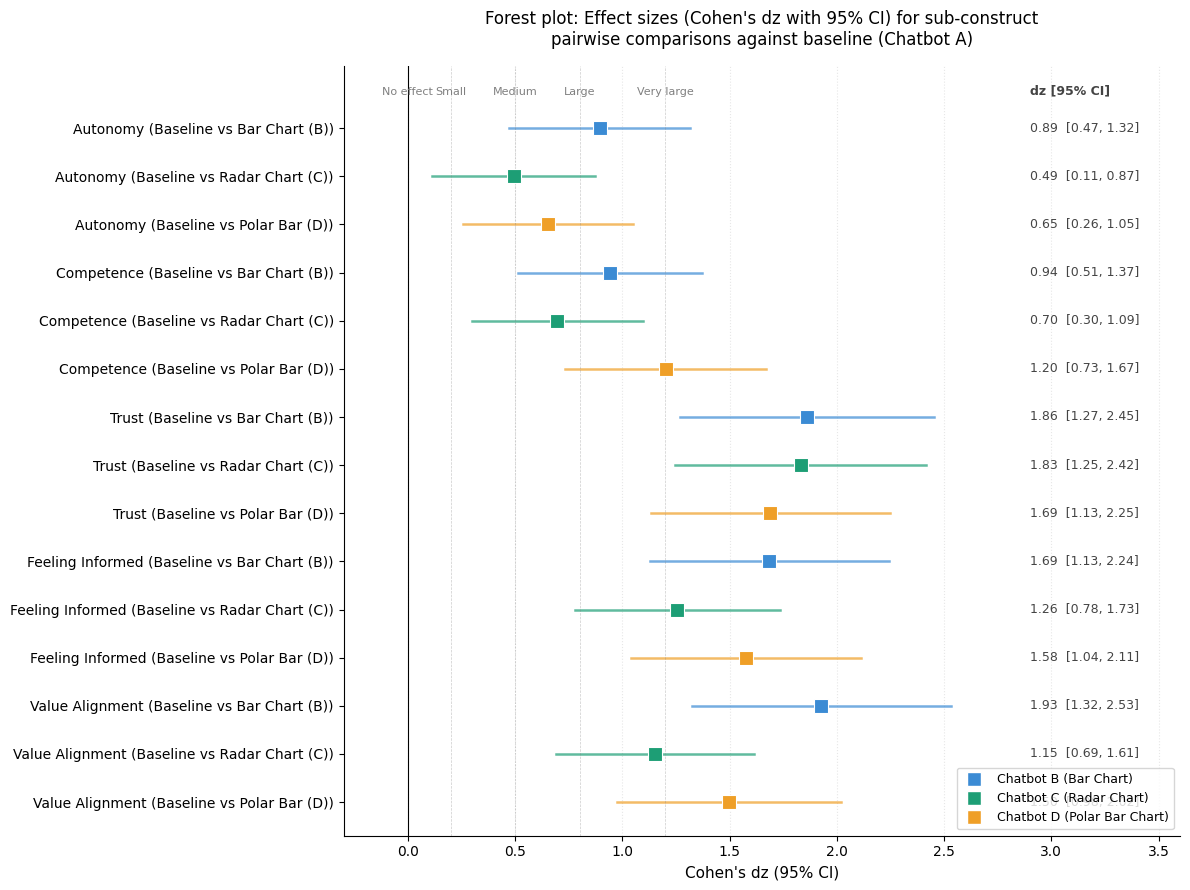

In [353]:
# Compute 95% CI for each Cohen's dz
# CI for dz: dz ± 1.96 * SE, where SE = sqrt((1/n) + (dz^2 / (2n)))
# n = 30 participants (paired)
n = 30

scale_cols = ["Autonomy", "Competence", "Trust", "Feeling_Informed", "Value_Alignment"]
visualisation_conditions = ["B", "C", "D"]
labels_map = {
    "B": "Bar Chart (B)",
    "C": "Radar Chart (C)",
    "D": "Polar Bar (D)"
}
colors = {"B": "#3B8BD4", "C": "#1D9E75", "D": "#EF9F27"}

# Build forest plot data
forest_data = []
for construct in scale_cols:
    for cond in visualisation_conditions:
        row = rq1_subconstruct_pairwise_table[
            (rq1_subconstruct_pairwise_table["Construct"] == construct) &
            (rq1_subconstruct_pairwise_table["Comparison"].str.endswith(cond))
        ]
        dz = row["Cohen's dz"].values[0]
        se = np.sqrt((1/n) + (dz**2 / (2*n)))
        ci_low = dz - 1.96 * se
        ci_high = dz + 1.96 * se
        forest_data.append({
            "construct": construct,
            "comparison": cond,
            "dz": dz,
            "ci_low": ci_low,
            "ci_high": ci_high,
            "label": f"{construct.replace('_', ' ')} (Baseline vs {labels_map[cond]})"
        })

# Create forest plot
fig, ax = plt.subplots(figsize=(12, 9))

y_positions = np.arange(len(forest_data))[::-1]

for i, row in enumerate(forest_data):
    y = y_positions[i]
    color = colors[row["comparison"]]

    # Confidence interval (horizontal line)
    ax.plot([row["ci_low"], row["ci_high"]], [y, y],
            color=color, linewidth=1.8, alpha=0.7)

    # Effect size point
    ax.scatter(row["dz"], y, color=color, marker="s", s=110,
               edgecolor="white", linewidth=0.8, zorder=3)

    # Numeric label on the right
    ax.text(2.9, y, f"{row['dz']:.2f}  [{row['ci_low']:.2f}, {row['ci_high']:.2f}]",
            fontsize=9, va="center", color="#444")

# Vertical reference lines
ax.axvline(0, color="black", linestyle="-", linewidth=0.8)
for threshold, label in [(0.2, "Small"), (0.5, "Medium"),
                         (0.8, "Large"), (1.2, "Very large")]:
    ax.axvline(threshold, color="gray", linestyle="--", linewidth=0.5, alpha=0.4)
    ax.text(threshold, len(forest_data) - 0.3, label,
            fontsize=8, color="gray", ha="center")

ax.text(0, len(forest_data) - 0.3, "No effect",
        fontsize=8, color="gray", ha="center")

# Y-axis labels
ax.set_yticks(y_positions)
ax.set_yticklabels([row["label"] for row in forest_data], fontsize=10)
ax.set_xlabel("Cohen's dz (95% CI)", fontsize=11)
ax.set_xlim(-0.3, 3.6)
ax.set_ylim(-0.7, len(forest_data) + 0.3)

# Clean spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle=":", alpha=0.3)

# Legend
legend_handles = [
    Line2D([0], [0], marker="s", color="w", markerfacecolor=colors["B"],
           markersize=10, label="Chatbot B (Bar Chart)"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=colors["C"],
           markersize=10, label="Chatbot C (Radar Chart)"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=colors["D"],
           markersize=10, label="Chatbot D (Polar Bar Chart)")
]
ax.legend(handles=legend_handles, loc="lower right", frameon=True, fontsize=9)

# Column header for numeric values
ax.text(2.9, len(forest_data) - 0.3, "dz [95% CI]",
        fontsize=9, color="#444", fontweight="bold")

# Title
ax.set_title("Forest plot: Effect sizes (Cohen's dz with 95% CI) for sub-construct\n"
             "pairwise comparisons against baseline (Chatbot A)",
             fontsize=12, pad=15)

plt.tight_layout()
plt.savefig("Figure1_ForestPlot_EffectSizes.png", dpi=300, bbox_inches="tight")
plt.show()

### RQ2: How do different value visualisation approaches influence users' trust, perceived autonomy, competence and feeling informed when interacting with chatbots?
 ####  Step 22: RQ2 Friedman Test (Omnibus Comparison Across All Four Conditions)
-  This step conducts the Friedman test for within-subjects design with 4 conditions (each participant
  experienced all conditions) for each of the five sub-constructs to examine whether scores differ across the chatbot conditions (A, B, C, D)

**Note on degrees of freedom:**
- For four conditions, df = k - 1 = 3, where k is the number of conditions.

In [357]:
# RQ2 compares all four conditions simultaneously (Chatbot A, B, C, D) to determine whether participants' perceptions vary across the
# baseline and the three visualisation formats. This non-parametric approach complements the parametric paired t-tests used in RQ1
# (which compared the baseline against the average of the three visualisation conditions).
values_scale_cols = ["Autonomy", "Competence", "Trust", "Feeling_Informed", "Value_Alignment"]
friedman_results = []

for outcome in values_scale_cols:
    wide_outcome = user_surveys_df.pivot(
        index="Participant_ID",
        columns="Condition",
        values=outcome
    )
    stat, p_value = friedmanchisquare(
        wide_outcome["A"],
        wide_outcome["B"],
        wide_outcome["C"],
        wide_outcome["D"]
    )
    friedman_results.append({
        "Construct": outcome,
        "Friedman χ²": round(stat, 3),
        "df": 3,
        "p": format_p_value(p_value),
        "p (exact)": f"{p_value:.4f}",
        "Significant at α = .05": interpret_significance(p_value)
    })

rq2_friedman_table = pd.DataFrame(friedman_results)
rq2_friedman_table

,Construct,Friedman χ²,df,p,p (exact),Significant at α = .05
0,Autonomy,23.934,3,p < .001,0.0000,Yes
1,Competence,32.411,3,p < .001,0.0000,Yes
2,Trust,55.178,3,p < .001,0.0000,Yes
3,Feeling_Informed,54.825,3,p < .001,0.0000,Yes
4,Value_Alignment,44.757,3,p < .001,0.0000,Yes


### Step 23: Raw Pairwise Wilcoxon Signed-rank Tests (No Correction Yet)
- Following the significant Friedman omnibus tests in Step 22 (all five sub-constructs significant at p < .001), this step conducts pairwise Wilcoxon signed-rank tests for each sub-construct.
**For four conditions (A, B, C, D), there are 6 pairwise comparisons:**
    - A vs B, A vs C, A vs D (baseline vs each visualisation)
    - B vs C, B vs D (between standard visualisations)
    - C vs D (radar vs polar bar)

In [360]:
values_scale_cols = ["Autonomy", "Competence", "Trust", "Feeling_Informed", "Value_Alignment"]
all_conditions = ["A", "B", "C", "D"]
condition_pairs = list(combinations(all_conditions, 2))
rq2_raw_wilcoxon_rows = []

for construct in values_scale_cols:
    wide_construct = user_surveys_df.pivot(
        index="Participant_ID",
        columns="Condition",
        values=construct
    )

    for condition_1, condition_2 in condition_pairs:
        w_stat, p_raw = wilcoxon(
            wide_construct[condition_1],
            wide_construct[condition_2],
            alternative="two-sided"
        )
        rq2_raw_wilcoxon_rows.append({
            "Construct": construct,
            "Comparison": f"Chatbot {condition_1} vs Chatbot {condition_2}",
            "Wilcoxon W": int(w_stat),
            "p_raw_numeric": p_raw,
            "p (uncorrected)": format_p_value(p_raw)
        })

rq2_raw_wilcoxon_table = pd.DataFrame(rq2_raw_wilcoxon_rows)
rq2_raw_wilcoxon_table[["Construct", "Comparison", "Wilcoxon W", "p (uncorrected)"]]

,Construct,Comparison,Wilcoxon W,p (uncorrected)
0,Autonomy,Chatbot A vs Chatbot B,24,p < .001
1,Autonomy,Chatbot A vs Chatbot C,80,0.015
2,Autonomy,Chatbot A vs Chatbot D,64,0.001
3,Autonomy,Chatbot B vs Chatbot C,92,0.020
4,Autonomy,Chatbot B vs Chatbot D,136,0.963
5,Autonomy,Chatbot C vs Chatbot D,119,0.153
6,Competence,Chatbot A vs Chatbot B,43,p < .001
7,Competence,Chatbot A vs Chatbot C,64,p < .001
8,Competence,Chatbot A vs Chatbot D,16,p < .001
9,Competence,Chatbot B vs Chatbot C,108,0.145


#### Step 24: RQ2 Pairwise Final Summary Table (Table 5)
- This step consolidates the RQ2 pairwise comparison results into the final reporting table. Building on the raw Wilcoxon results in Step 23, it applies Bonferroni correction and computes effect sizes:
    1. Applying Bonferroni correction within each sub-construct (alpha = 0.05 / 6 = 0.0083) to control family-wise error rate across the six pairwise comparisons.
    2. Effect size: Cohen's dz is computed for each pairwise comparison as the standardised effect size for paired data. Direction is preserved (positive dz = Cond1 > Cond2; negative dz = Cond1 < Cond2).
    3. Final summary: Each row reports the comparison, descriptive statistics for both conditions, the test statistic, the Bonferroni-corrected p-value, Cohen's dz, the effect size magnitude (Very small to Very large), and the final significance verdict.

In [364]:
# Conducts RM-ANOVA for each sub-construct. If sphericity was violated
# (Step 23a), Greenhouse-Geisser correction is automatically applied.
values_scale_cols = ["Autonomy", "Competence", "Trust", "Feeling_Informed", "Value_Alignment"]
all_conditions = ["A", "B", "C", "D"]
all_pairs = list(combinations(all_conditions, 2))
final_rows = []

for construct in values_scale_cols:
    wide = user_surveys_df.pivot(
        index="Participant_ID",
        columns="Condition",
        values=construct
    )

    # Get raw p-values for this sub-construct (from Step 23 table)
    construct_rows = rq2_raw_wilcoxon_table[
        rq2_raw_wilcoxon_table["Construct"] == construct
    ].reset_index(drop=True)
    raw_pvalues = construct_rows["p_raw_numeric"].values

    # Apply Bonferroni correction (alpha/6 = 0.0083)
    reject, p_corrected, _, _ = multipletests(
        raw_pvalues, alpha=0.05, method="bonferroni"
    )

    # Build final rows for this sub-construct
    for i, (cond1, cond2) in enumerate(all_pairs):
        cond1_m = wide[cond1].mean()
        cond1_sd = wide[cond1].std(ddof=1)
        cond2_m = wide[cond2].mean()
        cond2_sd = wide[cond2].std(ddof=1)
        diff = wide[cond1] - wide[cond2]
        dz = diff.mean() / diff.std(ddof=1)

        final_rows.append({
            "Construct": construct,
            "Comparison": f"Chatbot {cond1} vs Chatbot {cond2}",
            "Cond1 M (SD)": f"{cond1_m:.2f} ({cond1_sd:.2f})",
            "Cond2 M (SD)": f"{cond2_m:.2f} ({cond2_sd:.2f})",
            "Mean Difference": round(diff.mean(), 2),
            "Wilcoxon W": int(construct_rows.iloc[i]["Wilcoxon W"]),
            "p (Bonferroni)": format_p_value(p_corrected[i]),
            "Cohen's dz": round(dz, 3),
            "Effect Size": interpret_cohens_dz(dz),
            "Significant after Bonferroni": interpret_significance(p_corrected[i])
        })

rq2_pairwise_final_table = pd.DataFrame(final_rows)
rq2_pairwise_final_table

,Construct,Comparison,Cond1 M (SD),Cond2 M (SD),Mean Difference,Wilcoxon W,p (Bonferroni),Cohen's dz,Effect Size,Significant after Bonferroni
0,Autonomy,Chatbot A vs Chatbot B,4.72 (0.82),5.52 (0.57),-0.80,24,0.001,-0.894,Large,Yes
1,Autonomy,Chatbot A vs Chatbot C,4.72 (0.82),5.18 (0.68),-0.46,80,0.093,-0.493,Small,No
2,Autonomy,Chatbot A vs Chatbot D,4.72 (0.82),5.40 (0.66),-0.68,64,0.009,-0.653,Medium,Yes
3,Autonomy,Chatbot B vs Chatbot C,5.52 (0.57),5.18 (0.68),0.34,92,0.119,0.494,Small,No
4,Autonomy,Chatbot B vs Chatbot D,5.52 (0.57),5.40 (0.66),0.12,136,1.000,0.151,Very small,No
5,Autonomy,Chatbot C vs Chatbot D,5.18 (0.68),5.40 (0.66),-0.22,119,0.918,-0.222,Small,No
6,Competence,Chatbot A vs Chatbot B,4.69 (0.53),5.51 (0.72),-0.82,43,0.002,-0.941,Large,Yes
7,Competence,Chatbot A vs Chatbot C,4.69 (0.53),5.27 (0.67),-0.58,64,0.005,-0.696,Medium,Yes
8,Competence,Chatbot A vs Chatbot D,4.69 (0.53),5.41 (0.59),-0.72,16,p < .001,-1.202,Very large,Yes
9,Competence,Chatbot B vs Chatbot C,5.51 (0.72),5.27 (0.67),0.24,108,0.871,0.247,Small,No


**Result note:**  
The Friedman omnibus tests indicated significant differences across the four conditions for all five sub-constructs (Step 22). Pairwise Wilcoxon signed-rank tests with Bonferroni correction within each sub-construct (alpha = 0.05/6 = 0.0083) revealed which specific conditions differed (Table 5).
1. Baseline vs visualisation comparisons: 14 of 15 baseline-vs-visualisation comparisons were significant, with only the Autonomy A vs C comparison failing to reach significance (p = 0.093, dz = -0.49 Small). Effect sizes were predominantly very large (10 of 14 significant baseline comparisons).
2. Visualisation vs visualisation comparisons: The Bar Chart (B) significantly outperformed the Radar Chart (C) on two sub-constructs:
    - Trust: dz = 0.78, p = 0.004 (Medium effect)
    - Value Alignment: dz = 0.61, p = 0.025 (Medium effect)
    - This indicates that, despite both formats producing very large improvements over baseline, the Bar Chart provided additional benefits on the most consequential perception dimensions for chatbot users (trust in the system and alignment with personal values).
3. User-designed (D) vs standard (B, C) comparisons: None of the six comparisons between the user-designed Polar Bar
(D) and the two standard formats reached significance after correction. This finding directly addresses RQ3 and is examined in detail in further steps.

### Step 25: RQ2 Multi-panel Forest Plot (All 6 Pairwise Comparisons)
- This step visualises the 30 pairwise effect sizes from the RQ2 final summary table (Step 24, Table 5) as a multi-panel forest plot. Each panel represents one sub-construct, showing all six pairwise comparisons (A vs B, A vs C, A vs D, B vs C, B vs D, C vs D) with Cohen's dz and 95% confidence intervals.

**Visual encoding:**
- Colour distinguishes the type of comparison:
  - Blue = Baseline (A) vs visualisation (B, C, D)
  - Orange = Visualisation vs visualisation (B vs C, B vs D, C vs D) 
  correction:
    - Solid = Significant (filled marker, full-colour confidence bar)
    - Faded = Non-significant (semi-transparent)

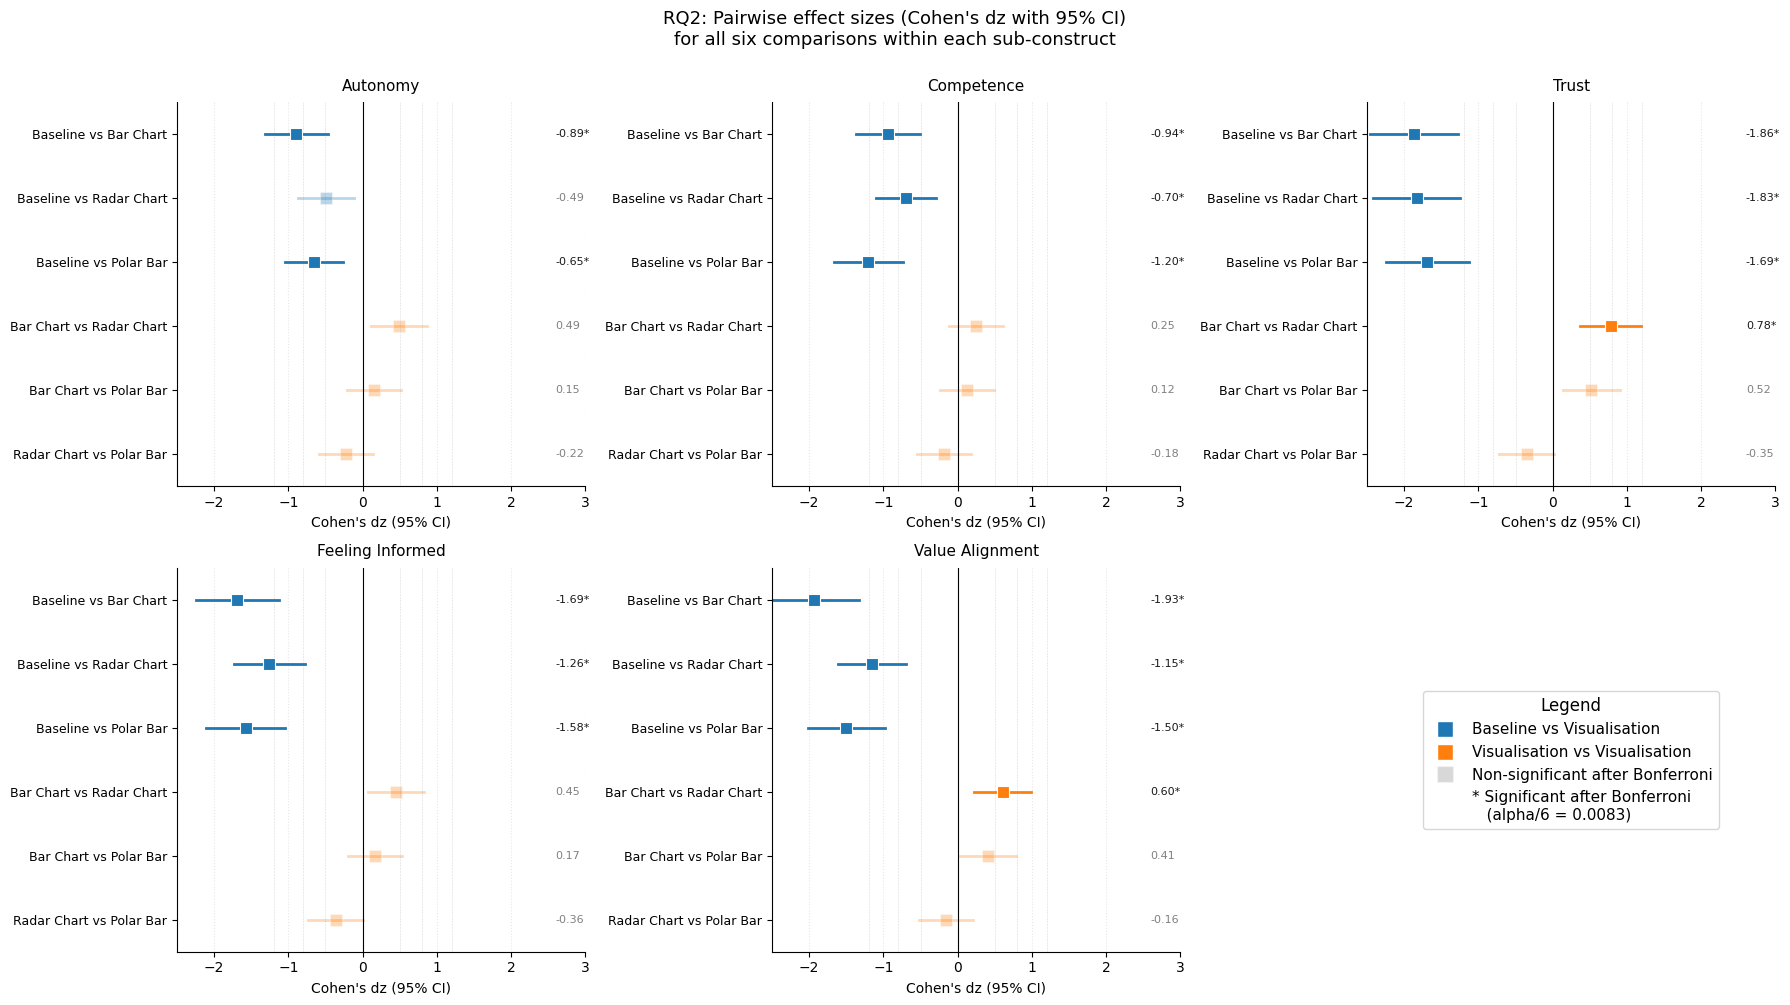

In [366]:
# Step 25: Forest Plot for RQ2 Visualisation-vs-Visualisation Comparisons
# This step visualises Cohen's dz with 95% confidence intervals for the
# pairwise comparisons among the three visualisation conditions (B vs C,
# B vs D, C vs D), separately for each of the five sub-constructs.

# 95% CI for paired Cohen's dz: dz ± 1.96 * SE
# SE = sqrt((1/n) + (dz^2 / (2n)))
n = 30
values_scale_cols = ["Autonomy", "Competence", "Trust",
                     "Feeling_Informed", "Value_Alignment"]
all_pairs = list(combinations(["A", "B", "C", "D"], 2))

# Use descriptive labels with chatbot type
chatbot_labels = {
    "A": "Baseline",
    "B": "Bar Chart",
    "C": "Radar Chart",
    "D": "Polar Bar"
}
pair_descriptive_labels = [
    f"{chatbot_labels[c1]} vs {chatbot_labels[c2]}"
    for c1, c2 in all_pairs
]

# Color scheme
pair_colors = {
    ("A", "B"): "#1F77B4",  # blue (baseline pair)
    ("A", "C"): "#1F77B4",
    ("A", "D"): "#1F77B4",
    ("B", "C"): "#FF7F0E",  # orange (visualisation pair)
    ("B", "D"): "#FF7F0E",
    ("C", "D"): "#FF7F0E"
}

# Create 2 rows × 3 columns figure
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()

for idx, construct in enumerate(values_scale_cols):
    ax = axes_flat[idx]

    for i, (cond1, cond2) in enumerate(all_pairs):
        comparison_str = f"Chatbot {cond1} vs Chatbot {cond2}"
        row = rq2_pairwise_final_table[
            (rq2_pairwise_final_table["Construct"] == construct) &
            (rq2_pairwise_final_table["Comparison"] == comparison_str)
        ]
        dz = row["Cohen's dz"].values[0]
        sig = row["Significant after Bonferroni"].values[0] == "Yes"
        se = np.sqrt((1/n) + (dz**2 / (2*n)))
        ci_low = dz - 1.96 * se
        ci_high = dz + 1.96 * se

        alpha = 1.0 if sig else 0.30
        y = len(all_pairs) - 1 - i
        color = pair_colors[(cond1, cond2)]

        # Confidence interval (horizontal line)
        ax.plot([ci_low, ci_high], [y, y],
                color=color, linewidth=2, alpha=alpha)

        # Effect size point
        ax.scatter(dz, y, color=color, marker="s", s=80,
                   edgecolor="white", linewidth=0.8, zorder=3, alpha=alpha)

        # Numeric label
        sig_marker = "*" if sig else ""
        text_alpha = 0.9 if sig else 0.5
        ax.text(2.6, y, f"{dz:.2f}{sig_marker}",
                fontsize=8, va="center", alpha=text_alpha)

    # Vertical reference lines
    ax.axvline(0, color="black", linestyle="-", linewidth=0.8)
    for threshold in [-1.2, -0.8, -0.5, 0.5, 0.8, 1.2]:
        ax.axvline(threshold, color="gray", linestyle="--",
                   linewidth=0.4, alpha=0.3)

    # Y-axis labels: every subplot gets descriptive labels
    ax.set_yticks(range(len(all_pairs))[::-1])
    ax.set_yticklabels(pair_descriptive_labels, fontsize=9)

    # X axis
    ax.set_xlim(-2.5, 3.0)
    ax.set_ylim(-0.5, len(all_pairs) - 0.5)
    ax.set_xlabel("Cohen's dz (95% CI)", fontsize=10)
    ax.set_title(construct.replace("_", " "), fontsize=11, pad=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", linestyle=":", alpha=0.3)

# Hide the last (6th) panel and place legend there
axes_flat[5].axis("off")

# Build legend in the bottom-right empty space
legend_handles = [
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#1F77B4",
           markersize=12, label="Baseline vs Visualisation"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="#FF7F0E",
           markersize=12, label="Visualisation vs Visualisation"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="gray",
           markersize=12, alpha=0.30,
           label="Non-significant after Bonferroni"),
    Line2D([0], [0], marker="", color="w",
           label="* Significant after Bonferroni\n   (alpha/6 = 0.0083)")
]
axes_flat[5].legend(
    handles=legend_handles,
    loc="center",
    fontsize=11,
    frameon=True,
    title="Legend",
    title_fontsize=12
)

# Title
fig.suptitle(
    "RQ2: Pairwise effect sizes (Cohen's dz with 95% CI)\n"
    "for all six comparisons within each sub-construct",
    fontsize=13, y=1.00
)

plt.tight_layout()
plt.savefig("Figure2_RQ2_MultiPanel_AllPairs.png",
            dpi=300, bbox_inches="tight")
plt.show()

### RQ3: How do user-designed value visualisations compare to standard visualisation formats (such as bar and radar charts) in terms of impacting user perceptions?
#### Step 26: RQ3 Focused Pairwise Comparison Table (Table 6)
- RQ3 examines whether the user-designed visualisation (Polar Bar, D) compares favourably to the two standard visualisation formats (Bar Chart, B; Radar Chart, C). The relevant pairwise comparisons are extracted from the RQ2 pairwise table (Step 24, Table 6) without re-running statistical tests.
- This step does not run any new statistical tests. Instead, it re-organises the relevant pairwise comparisons from the RQ2 results (Step 24, Table 5) into a focused RQ3 perspective. The 10 relevant pairwise comparisons (5 sub-constructs × 2 standard formats) are extracted and reorganised with explicit interpretation labels.
- Comparisons are presented as "D vs Standard" so that:
    - Positive Cohen's dz means D > Standard
    - Negative Cohen's dz means D < Standard

In [370]:
values_scale_cols = ["Autonomy", "Competence", "Trust", "Feeling_Informed", "Value_Alignment"]
rq3_rows = []

for construct in values_scale_cols:
    wide = user_surveys_df.pivot(
        index="Participant_ID",
        columns="Condition",
        values=construct
    )

    # Compute D vs B and D vs C with D as reference
    for standard_cond, standard_label in [("B", "Bar Chart"), ("C", "Radar Chart")]:
        # Extract from RQ2 table - comparison stored as "Standard vs D"
        rq2_comparison_str = f"Chatbot {standard_cond} vs Chatbot D"
        rq2_row = rq2_pairwise_final_table[
            (rq2_pairwise_final_table["Construct"] == construct) &
            (rq2_pairwise_final_table["Comparison"] == rq2_comparison_str)
        ].iloc[0]

        # Reverse the direction: we want D vs Standard (so D - Standard)
        d_m = wide["D"].mean()
        d_sd = wide["D"].std(ddof=1)
        std_m = wide[standard_cond].mean()
        std_sd = wide[standard_cond].std(ddof=1)
        diff_d_minus_standard = wide["D"] - wide[standard_cond]
        dz_d_vs_standard = diff_d_minus_standard.mean() / diff_d_minus_standard.std(ddof=1)

        # Determine direction interpretation
        if rq2_row["Significant after Bonferroni"] == "No":
            interpretation = "No significant difference"
        elif diff_d_minus_standard.mean() > 0:
            interpretation = f"D significantly higher than {standard_label}"
        else:
            interpretation = f"D significantly lower than {standard_label}"

        rq3_rows.append({
            "Construct": construct,
            "Comparison": f"Polar Bar (D) vs {standard_label} ({standard_cond})",
            "D M (SD)": f"{d_m:.2f} ({d_sd:.2f})",
            "Standard M (SD)": f"{std_m:.2f} ({std_sd:.2f})",
            "Mean Difference (D - Standard)": round(diff_d_minus_standard.mean(), 2),
            "Wilcoxon W": rq2_row["Wilcoxon W"],
            "p (Bonferroni)": rq2_row["p (Bonferroni)"],
            "Cohen's dz (D vs Standard)": round(dz_d_vs_standard, 3),
            "Effect Size": interpret_cohens_dz(dz_d_vs_standard),
            "Interpretation": interpretation
        })

rq3_focused_table = pd.DataFrame(rq3_rows)
rq3_focused_table

,Construct,Comparison,D M (SD),Standard M (SD),Mean Difference (D - Standard),Wilcoxon W,p (Bonferroni),Cohen's dz (D vs Standard),Effect Size,Interpretation
0,Autonomy,Polar Bar (D) vs Bar Chart (B),5.40 (0.66),5.52 (0.57),-0.12,136,1.000,-0.151,Very small,No significant difference
1,Autonomy,Polar Bar (D) vs Radar Chart (C),5.40 (0.66),5.18 (0.68),0.22,119,0.918,0.222,Small,No significant difference
2,Competence,Polar Bar (D) vs Bar Chart (B),5.41 (0.59),5.51 (0.72),-0.10,135,1.000,-0.125,Very small,No significant difference
3,Competence,Polar Bar (D) vs Radar Chart (C),5.41 (0.59),5.27 (0.67),0.14,97,1.000,0.185,Very small,No significant difference
4,Trust,Polar Bar (D) vs Bar Chart (B),5.37 (0.38),5.66 (0.51),-0.29,100,0.066,-0.521,Medium,No significant difference
5,Trust,Polar Bar (D) vs Radar Chart (C),5.37 (0.38),5.16 (0.47),0.21,137,0.500,0.349,Small,No significant difference
6,Feeling_Informed,Polar Bar (D) vs Bar Chart (B),5.93 (0.69),6.10 (0.76),-0.17,82,1.000,-0.169,Very small,No significant difference
7,Feeling_Informed,Polar Bar (D) vs Radar Chart (C),5.93 (0.69),5.53 (1.22),0.40,51,0.339,0.363,Small,No significant difference
8,Value_Alignment,Polar Bar (D) vs Bar Chart (B),5.49 (0.53),5.74 (0.57),-0.26,103,0.230,-0.409,Small,No significant difference
9,Value_Alignment,Polar Bar (D) vs Radar Chart (C),5.49 (0.53),5.38 (0.59),0.11,149,1.000,0.158,Very small,No significant difference


- RQ3 compared the user-designed polar bar chart condition (Chatbot D) with the two standard visualisation formats: the bar chart (Chatbot B) and the radar chart (Chatbot C). Across all five constructs, the polar bar chart did not significantly differ from either the bar chart or the radar chart after Bonferroni correction. Descriptively, the polar bar chart scored slightly lower than the bar chart across autonomy, competence, trust, feeling informed, and value alignment, but none of these differences reached statistical significance. In contrast, the polar bar chart scored slightly higher than the radar chart across all five constructs, although these differences were also not statistically significant. These results suggest that the user-designed polar bar chart performed comparably to the standard visualisation formats.


## Secondary Analysis: User-Defined Value Adjustments
- This section presents a supplementary analysis based on a separate dataset capturing how participants would prefer to reconfigure the chatbot's value priorities. Under three of the four conditions (Bar Chart, Radar Chart, Polar Bar), participants were given the option to modify the system-defined values (Privacy, Informed Consent, Autonomy, Universal Usability, Courtesy) to reflect their own preferences.
- This dataset complements the questionnaire-based main analyses (RQ1, RQ2, RQ3) by providing a behavioural lens on how participants engaged with the visualised value profile. Whereas Q20-Q22 captured participants' perceptions of the chatbot's value alignment, the user-defined value adjustments capture how participants would change and reshape the chatbot's value system during the interaction.
#### Step 27a: Load User-Defined Values Dataset
- In addition to the questionnaire data analysed for RQ1-RQ3, a separate dataset captures participants' adjustments to the chatbot's value priorities under three visualisation conditions: Bar Chart (B), Radar Chart (C), and the user-designed Polar Bar Chart (D). Under each condition, participants were given the option to modify five values (Privacy, Informed Consent, Autonomy, Universal Usability, Courtesy) from their system-defined defaults

In [385]:
df_user_defined_values = pd.read_excel(
    "User_defined_Value_Result.xlsx",
    sheet_name=0
)
# Inspect basic structure
print(f"Dataset shape: {df_user_defined_values.shape[0]} rows x {df_user_defined_values.shape[1]} columns")
print(f"\nColumn names:\n{list(df_user_defined_values.columns)}")
print(f"\nFirst 5 rows:")
df_user_defined_values.head()

Dataset shape: 90 rows x 10 columns

Column names:
['participant_base_id', 'participant_id', 'condition', 'mode', 'timestamp', 'Privacy', 'Informed Consent', 'Courtesy', 'Autonomy', 'Universal Usability']

First 5 rows:


,participant_base_id,participant_id,condition,mode,timestamp,Privacy,Informed Consent,Courtesy,Autonomy,Universal Usability
0,1,PB001,bar,user_defined,2026-04-08 12:25:40,1,2,3,1,2
1,1,PR001,radar,user_defined,2026-04-08 12:43:30,1,2,3,1,2
2,1,PC001,codesign,user_defined,2026-04-08 13:02:26,1,2,3,1,3
3,2,PB002,bar,user_defined,2026-04-08 12:38:12,1,2,3,2,3
4,2,PC002,codesign,user_defined,2026-04-08 12:53:22,1,2,3,2,3


### Step 27b: Mark Each Value Modification (Modified vs Unchanged)
- In the chatbot conditions B (Bar), C (Radar), and D (Co-design), each participant was asked to adjust five values (Privacy, Informed Consent, Autonomy, Universal Usability, Courtesy) to reflect their preferred priority for the chatbot system. 

- The system started with fixed default values:
    - System defaults:
        -  Privacy             = Low (1)
        - Informed Consent    = Low (1)
        - Autonomy            = Medium (2)
        - Universal Usability = High (3)
        - Courtesy            = High (3)


In [387]:
# System defaults (1=Low, 2=Medium, 3=High)
system_defaults_values_setting = {
    "Privacy": 1,
    "Informed Consent": 1,
    "Autonomy": 2,
    "Universal Usability": 3,
    "Courtesy": 3
}

# Map condition codes to match main analysis
visualisation_chatbot_condition_map = {
    "bar": "B",
    "radar": "C",
    "codesign": "D"
}
df_user_defined_values["Condition"] = df_user_defined_values["condition"].map(visualisation_chatbot_condition_map)

# Reshape to long format
value_cols = ["Privacy", "Informed Consent", "Courtesy", "Autonomy", "Universal Usability"]

user_modifications = df_user_defined_values.melt(
    id_vars=["participant_base_id", "Condition"],
    value_vars=value_cols,
    var_name="Value",
    value_name="User_Choice"
)

# Add system default and modification flags
user_modifications["System_Default"] = user_modifications["Value"].map(system_defaults_values_setting)
user_modifications["Modified"] = (
    user_modifications["User_Choice"] != user_modifications["System_Default"]
)
user_modifications["Direction"] = user_modifications.apply(
    lambda row: (
        "Unchanged" if row["User_Choice"] == row["System_Default"]
        else "Increased" if row["User_Choice"] > row["System_Default"]
        else "Decreased"
    ),
    axis=1
)

# Sanity check
print(f"Total rows: {len(user_modifications)}")
print(f"Expected: 30 participants × 3 conditions × 5 values = 450")
print(f"\nDirection distribution:")
print(user_modifications["Direction"].value_counts())

user_modifications.head(15)

Total rows: 450
Expected: 30 participants × 3 conditions × 5 values = 450

Direction distribution:
Direction
Unchanged    218
Increased    119
Decreased    113
Name: count, dtype: int64


,participant_base_id,Condition,Value,User_Choice,System_Default,Modified,Direction
0,1,B,Privacy,1,1,False,Unchanged
1,1,C,Privacy,1,1,False,Unchanged
2,1,D,Privacy,1,1,False,Unchanged
3,2,B,Privacy,1,1,False,Unchanged
4,2,D,Privacy,1,1,False,Unchanged
5,2,C,Privacy,1,1,False,Unchanged
6,3,D,Privacy,1,1,False,Unchanged
7,3,C,Privacy,1,1,False,Unchanged
8,3,B,Privacy,1,1,False,Unchanged
9,4,D,Privacy,2,1,True,Increased


#### Step 27c: Summarise user-defined value changes by value
- This step computes how often each of the five values was modified from the system default, aggregated across the three visualisation conditions. The result identifies which values participants most wanted to change.

In [388]:
user_value_change_summary = (
    user_modifications
    .groupby("Value")
    .agg(
        Total=("Modified", "count"),
        Changed_Count=("Modified", "sum")
    )
    .reset_index()
)
user_value_change_summary["Unchanged_Count"] = (
    user_value_change_summary["Total"] - user_value_change_summary["Changed_Count"]
)
# Modification rate as percentage
user_value_change_summary["Change_Rate (%)"] = (
    user_value_change_summary["Changed_Count"] / user_value_change_summary["Total"] * 100
).round(1)

user_value_change_summary = user_value_change_summary.sort_values(
    "Change_Rate (%)", ascending=False
).reset_index(drop=True)
user_value_change_summary

,Value,Total,Changed_Count,Unchanged_Count,Change_Rate (%)
0,Autonomy,90,55,35,61.1
1,Courtesy,90,50,40,55.6
2,Informed Consent,90,46,44,51.1
3,Privacy,90,43,47,47.8
4,Universal Usability,90,38,52,42.2


**Result note:**  
Across the 30 participants and with 90 user-defined value (bar+radar+co-design chart) observations for each value, autonomy was the most frequently modified value (61.1%), followed by courtesy (55.6%), informed consent (51.1%), privacy (47.8%), and universal usability (42.2%). These results suggest that participants did not simply accept the system-defined value profile, but actively adjusted several values after viewing the visualisations. Autonomy showed the highest modification rate, indicating that participants were particularly likely to reconsider the level of control or choice the chatbot should provide.

#### Step 27d: Summarise user-defined value changes by value and direction
- This step shows the breakdown of modification direction (Increased,Decreased, Unchanged) for each value, complementing the aggregated modification rate from Step 27c.

- Reminder on ceiling/floor effects:
    - Privacy and Informed Consent (default Low) can only be Increased.
    - Universal Usability and Courtesy (default High) can only be Decreased.
    - Only Autonomy (default Medium) can be modified bidirectionally.

In [396]:
direction_by_value = (
    user_modifications
    .groupby(["Value", "Direction"])
    .size()
    .reset_index(name="Count")
)

direction_by_value_pivot = direction_by_value.pivot(
    index="Value",
    columns="Direction",
    values="Count"
).fillna(0).astype(int)

# Add row-wise total
direction_by_value_pivot["Total"] = direction_by_value_pivot.sum(axis=1)

# Add percentage columns for each direction
for col in ["Increased", "Decreased", "Unchanged"]:
    if col in direction_by_value_pivot.columns:
        direction_by_value_pivot[f"{col} (%)"] = (
            direction_by_value_pivot[col] / direction_by_value_pivot["Total"] * 100
        ).round(1)

direction_by_value_pivot

Direction,Decreased,Increased,Unchanged,Total,Increased (%),Decreased (%),Unchanged (%)
Value,,,,,,,
Autonomy,25,30,35,90,33.3,27.8,38.9
Courtesy,50,0,40,90,0.0,55.6,44.4
Informed Consent,0,46,44,90,51.1,0.0,48.9
Privacy,0,43,47,90,47.8,0.0,52.2
Universal Usability,38,0,52,90,0.0,42.2,57.8


**Result note:**  
The direction of user-defined value adjustments showed different patterns across the five stakeholders values. Autonomy, which was initially set to Medium, showed the most mixed pattern: 33.3% of observations increased autonomy, 27.8% decreased it, and 38.9% left it unchanged. This suggests that participants differed in how much control or choice they wanted the chatbot to provide.

For the two values initially set to Low, informed consent and privacy, adjustments could only move upward or remain unchanged. Informed consent was increased in 51.1% of observations, while privacy was increased in 47.8%. This indicates that many participants challenged the low system-defined levels for these values.

For values initially set to High, courtesy and universal usability, adjustments could only move downward or remain unchanged. Courtesy was decreased in 55.6% of observations, whereas universal usability was decreased in 42.2% and remained unchanged in 57.8%. This suggests that participants were more likely to retain a high level of universal usability than courtesy in the academic support context.

#### Step 27e: Modification Rate per Condition (Chatbot B, C, D)
- This step examines whether participants modified values at different rates depending on which visualisation condition they experienced. Although system defaults were identical across all three conditions (B, C, D), the modification rate may differ depending on how each visualisation format afforded engagement with the value profile.

In [397]:
# This analysis supports RQ3 by examining whether the user-designed Polar Bar (D) elicited a distinctive form of engagement compared to
# the standard Bar (B) and Radar (C) charts. While the main RQ3 analysis showed that D and standard formats did not significantly differ on
# perceptual outcomes, modification patterns provide an additional behavioural lens for understanding what each format affords.
visualisation_chatbot_condition_change_summary = (
    user_modifications
    .groupby("Condition")
    .agg(
        Total=("Modified", "count"),
        Changed_Count=("Modified", "sum")
    )
    .reset_index()
)

visualisation_chatbot_condition_change_summary["Unchanged_Count"] = (
    visualisation_chatbot_condition_change_summary["Total"] - visualisation_chatbot_condition_change_summary["Changed_Count"]
)

visualisation_chatbot_condition_change_summary["Change_Rate (%)"] = (
    visualisation_chatbot_condition_change_summary["Changed_Count"] / visualisation_chatbot_condition_change_summary["Total"] * 100
).round(1)

visualisation_chatbot_condition_change_summary

,Condition,Total,Changed_Count,Unchanged_Count,Change_Rate (%)
0,B,150,76,74,50.7
1,C,150,78,72,52.0
2,D,150,78,72,52.0


**Result note:**  
The rate of user-defined value adjustments was very similar across the three visualisation conditions. Participants modified 50.7% of value observations in the bar chart condition, 52.0% in the radar chart condition, and 52.0% in the custom chart condition. This suggests that all three value visualisation approaches encouraged a comparable level of active engagement with the chatbot’s value profile. The custom chart did not produce more frequent value adjustments than the standard formats, but it also did not result in lower engagement.

#### Step 27f: Value modification rates by condition and value
- Building on Steps 27c-27e, this step examines the interaction between visualisation condition and value: whether different visualisation formats lead participants to modify specific values more or less often.
- Step 27e showed that aggregated modification rates were nearly identical across the three conditions (50.7%-52.0%). This step investigates whether that surface-level uniformity masks different value-specific patterns.

In [399]:
visualisation_chatbot_condition_value_change_summary = (
    user_modifications
    .groupby(["Condition", "Value"])
    .agg(
        Total=("Modified", "count"),
        Changed_Count=("Modified", "sum")
    )
    .reset_index()
)

visualisation_chatbot_condition_value_change_summary["Change_Rate (%)"] = (
    visualisation_chatbot_condition_value_change_summary["Changed_Count"] / visualisation_chatbot_condition_value_change_summary["Total"] * 100
).round(1)

# Pivot to wide format: rows = Value, columns = Condition
condition_value_pivot = visualisation_chatbot_condition_value_change_summary.pivot(
    index="Value",
    columns="Condition",
    values="Change_Rate (%)"
)

# Order values by overall modification rate (consistent with Step 27c)
value_order = ["Autonomy", "Courtesy", "Informed Consent", "Privacy", "Universal Usability"]
condition_value_pivot = condition_value_pivot.reindex(value_order)

# Add a 'Mean' column showing average across the three conditions
condition_value_pivot["Mean"] = condition_value_pivot.mean(axis=1).round(1)

condition_value_pivot

Condition,B,C,D,Mean
Value,,,,
Autonomy,56.7,63.3,63.3,61.1
Courtesy,60.0,56.7,50.0,55.6
Informed Consent,50.0,46.7,56.7,51.1
Privacy,46.7,43.3,53.3,47.8
Universal Usability,40.0,50.0,36.7,42.2


#### Step 27g: Q21 mean and SD per value
- This step computes the mean and standard deviation of participants' Q21 alignment ratings for each of the five values, aggregated across all four conditions (A, B, C, D, with 30 observations per condition, totalling 120 observations per value).
- Q21 captured participants' self-reported perception of how well the chatbot aligned with each value, on a 7-point Likert scale (1 = Strongly Disagree, 7 = Strongly Agree). 

**The five Q21 sub-items are:**
- Q21a: Universal Usability
- Q21b: Informed Consent
- Q21c: Autonomy
- Q21d: Privacy
- Q21e: Courtesy

In [402]:
survey_Q21_value_items = {
    "Universal Usability": "Q21a",
    "Informed Consent": "Q21b",
    "Autonomy": "Q21c",
    "Privacy": "Q21d",
    "Courtesy": "Q21e"
}

survey_q21_summary = []
for value, col in survey_Q21_value_items.items():
    survey_q21_summary.append({
        "Value": value,
        "Q21_Mean": user_surveys_df[col].mean(),
        "Q21_SD": user_surveys_df[col].std(ddof=1)
    })

survey_q21_summary = pd.DataFrame(survey_q21_summary).round(2)
print(survey_q21_summary)

                 Value  Q21_Mean  Q21_SD
0  Universal Usability      5.10    1.26
1     Informed Consent      5.17    1.33
2             Autonomy      5.28    1.30
3              Privacy      5.42    1.34
4             Courtesy      5.23    1.52


#### Step 27h: Combined summary (Q21 + Modification + Direction)
- This step integrates three complementary data sources into a single supplementary descriptive table:
1. Q21 alignment ratings (Step 27g): Self-reported perception of how well the chatbot aligned with each value. Reported as Mean and SD on a 7-point Likert scale.
2. Modification rate (Step 27c): Proportion of all 90 observations (30 participants × 3 conditions) in which the participant changed the value from the system default. Reported as Changed_Count and Change_Rate (%).
3. Direction breakdown (Step 27d): For each value, counts and percentages of Increased, Decreased, and Unchanged modifications.

In [406]:
value_alignment_adjustment_summary = survey_q21_summary.copy()

# Merge modification rate (Changed_Count + Change_Rate %)
value_alignment_adjustment_summary = value_alignment_adjustment_summary.merge(
    user_value_change_summary[["Value", "Changed_Count", "Change_Rate (%)"]],
    on="Value",
    how="left"
)

# Merge direction breakdown (Increased / Decreased / Unchanged + percentages)
direction_summary = direction_by_value_pivot.reset_index()
value_alignment_adjustment_summary = value_alignment_adjustment_summary.merge(
    direction_summary,
    on="Value",
    how="left"
)

# Add system default for context
default_labels = {
    "Privacy": "Low",
    "Informed Consent": "Low",
    "Autonomy": "Medium",
    "Universal Usability": "High",
    "Courtesy": "High"
}
value_alignment_adjustment_summary["System Default"] = (
    value_alignment_adjustment_summary["Value"].map(default_labels)
)

# Drop redundant Total column if present
if "Total" in value_alignment_adjustment_summary.columns:
    value_alignment_adjustment_summary = value_alignment_adjustment_summary.drop(columns=["Total"])

# Reorder columns
column_order = [
    "Value",
    "System Default",
    "Q21_Mean",
    "Q21_SD",
    "Changed_Count",
    "Change_Rate (%)",
    "Increased",
    "Decreased",
    "Unchanged",
    "Increased (%)",
    "Decreased (%)",
    "Unchanged (%)"
]
keep_cols = [c for c in column_order if c in value_alignment_adjustment_summary.columns]
value_alignment_adjustment_summary = value_alignment_adjustment_summary[keep_cols]

# Order rows by overall modification rate (most-modified first)
value_order = ["Autonomy", "Courtesy", "Informed Consent", "Privacy", "Universal Usability"]
value_alignment_adjustment_summary = (
    value_alignment_adjustment_summary
    .set_index("Value")
    .reindex(value_order)
    .reset_index()
)
value_alignment_adjustment_summary

,Value,System Default,Q21_Mean,Q21_SD,Changed_Count,Change_Rate (%),Increased,Decreased,Unchanged,Increased (%),Decreased (%),Unchanged (%)
0,Autonomy,Medium,5.28,1.30,55,61.1,30,25,35,33.3,27.8,38.9
1,Courtesy,High,5.23,1.52,50,55.6,0,50,40,0.0,55.6,44.4
2,Informed Consent,Low,5.17,1.33,46,51.1,46,0,44,51.1,0.0,48.9
3,Privacy,Low,5.42,1.34,43,47.8,43,0,47,47.8,0.0,52.2
4,Universal Usability,High,5.10,1.26,38,42.2,0,38,52,0.0,42.2,57.8


**Result Note:** 
- Q21 ratings indicated generally positive perceived alignment across the five human values, with mean scores ranging from 5.10 to 5.42. However, user-defined adjustments showed that participants still frequently modified the system-defined value levels. Autonomy had the highest change rate (61.1%), with both upward and downward adjustments, suggesting mixed expectations about the level of choice and control the chatbot should provide. Informed consent and privacy, both initially set to Low, were often increased, while courtesy and universal usability, both initially set to High, were decreased or left unchanged. These findings suggest that perceived value alignment did not necessarily mean full acceptance of the predefined value profile.

#### Step 27i: Visualisation - Q21 value Alignment vs Behavioural Adjustment (Figure 3)
- This step visualises the combined evidence from Step 27h, presenting the relationship between participants' self-reported alignment ratings (Q21) and their behavioural value adjustments side by side.

**Visual encoding:**
- Y-axis (both panels): Five values, ordered with the most-modified (Autonomy) at the top and the least-modified (Universal Usability) at the bottom.
- Left panel x-axis: Q21 Likert scale (1-7), with midpoint marker.
- Right panel x-axis: Percentage (0-100%), with overall modification rate appended (e.g., "61.1% modified").

In [ ]:
plot_data = value_alignment_adjustment_summary.copy()
plot_data = plot_data.iloc[::-1].reset_index(drop=True)  # reverse for top-down

values = plot_data["Value"].tolist()
y_positions = np.arange(len(values))

fig, axes = plt.subplots(
    nrows=1, ncols=2,
    figsize=(14, 5.5),
    gridspec_kw={"width_ratios": [1, 1.2], "wspace": 0.35}
)

ax_left = axes[0]
q21_means = plot_data["Q21_Mean"].values
q21_sds = plot_data["Q21_SD"].values

ax_left.barh(
    y_positions, q21_means, xerr=q21_sds,
    color="#3B8BD4", edgecolor="white", height=0.65,
    error_kw={"elinewidth": 1.0, "capsize": 4, "ecolor": "#475569"}
)

# Scale midpoint reference line
ax_left.axvline(4, color="gray", linestyle=":", linewidth=0.8, alpha=0.6)
ax_left.text(4, len(values) - 0.3, "Midpoint",
             fontsize=8, color="gray", ha="center")

# Annotate within the bar chart center area 
for i, (m, sd) in enumerate(zip(q21_means, q21_sds)):
    ax_left.text(m / 2.3, i, f"M = {m:.2f}, SD = {sd:.2f}",
                 va="center", ha="center", fontsize=9,
                 color="white", fontweight="bold")

ax_left.set_yticks(y_positions)
ax_left.set_yticklabels(values, fontsize=9)
ax_left.set_xlabel("Q21 Alignment Mean (1–7) with SD error bars", fontsize=10)
ax_left.set_xlim(0, 7.5)
ax_left.set_xticks([1, 2, 3, 4, 5, 6, 7])
ax_left.set_title("Perceived Value Alignment (Q21)", fontsize=11, pad=10)
ax_left.spines["top"].set_visible(False)
ax_left.spines["right"].set_visible(False)
ax_left.grid(axis="x", linestyle=":", alpha=0.4)

ax_right = axes[1]

increased_pct = plot_data["Increased (%)"].values
decreased_pct = plot_data["Decreased (%)"].values
unchanged_pct = plot_data["Unchanged (%)"].values

colour_increased = "#1D9E75"
colour_decreased = "#EF5A5A"
colour_unchanged = "#CBD5E0"

ax_right.barh(y_positions, increased_pct, color=colour_increased,
              edgecolor="white", height=0.65, label="Increased")
ax_right.barh(y_positions, decreased_pct, left=increased_pct,
              color=colour_decreased, edgecolor="white", height=0.65, label="Decreased")
ax_right.barh(y_positions, unchanged_pct,
              left=increased_pct + decreased_pct,
              color=colour_unchanged, edgecolor="white", height=0.65, label="Unchanged")

# Annotate each segment
for i in range(len(values)):
    inc = increased_pct[i]
    dec = decreased_pct[i]
    unc = unchanged_pct[i]

    if inc >= 7:
        ax_right.text(inc / 2, i, f"{inc:.1f}%",
                      va="center", ha="center", fontsize=8,
                      color="white", fontweight="bold")
    if dec >= 7:
        ax_right.text(inc + dec / 2, i, f"{dec:.1f}%",
                      va="center", ha="center", fontsize=8,
                      color="white", fontweight="bold")
    if unc >= 7:
        ax_right.text(inc + dec + unc / 2, i, f"{unc:.1f}%",
                      va="center", ha="center", fontsize=8,
                      color="#333", fontweight="bold")

# Annotate overall modification rate next to each bar
for i, row in plot_data.iterrows():
    ax_right.text(102, i, f"{row['Change_Rate (%)']:.1f}% modified",
                  va="center", fontsize=8, color="#666")

ax_right.set_yticks(y_positions)
ax_right.set_yticklabels(values, fontsize=9)
ax_right.set_xlabel(
    "Direction of Modification\n(% of 30 participants × 3 visualisation conditions)",
    fontsize=10
)
ax_right.set_xlim(0, 125)
ax_right.set_xticks([0, 20, 40, 60, 80, 100])
ax_right.set_title("Behavioural Value Adjustments", fontsize=11, pad=10)
ax_right.spines["top"].set_visible(False)
ax_right.spines["right"].set_visible(False)
ax_right.grid(axis="x", linestyle=":", alpha=0.4)

# Legend above the right panel 
ax_right.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.30),
    ncol=3, fontsize=9, frameon=False
)

# To set the figure title
fig.suptitle(
    "Perceived alignment VS behavioural adjustment for the five values\n"
    "(supplementary descriptive analysis)",
    fontsize=12, y=1.04
)

plt.tight_layout()
plt.savefig("Figure3_Alignment_vs_Adjustment.png", dpi=300, bbox_inches="tight")
plt.show()

NameError: name 'value_alignment_adjustment_summary' is not defined